In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


[INFO] Verifying dataset directory: /content/drive/MyDrive/BDMediHerb/Original Dataset
[INFO] Dataset successfully loaded. Total samples: 3800
[INFO] Number of classes detected: 19

[INFO] Initiating class distribution analysis...

[REPORT] Total Class-wise Image Count Table:
 Class ID         Class Name  Image Count
        0 Belleric Myrobalan          200
        1        Black Cumin          200
        2       Black Pepper          200
        3           Cardamom          200
        4 Chebulic Myrobalan          200
        5           Cinnamon          200
        6              Clove          200
        7        Cumin Seeds          200
        8    Fenugreek Seeds          200
        9          Flax Seed          199
       10             Garlic          200
       11             Ginger          200
       12         Gooseberry          200
       13               Mace          201
       14             Nutmeg          200
       15     Psoralea Fruit          200
       16

/tmp/ipykernel_516/3961485597.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


[INFO] Distribution graph saved successfully to: /content/drive/MyDrive/BDMediHerb/Outputs/Dataset_Distribution.png


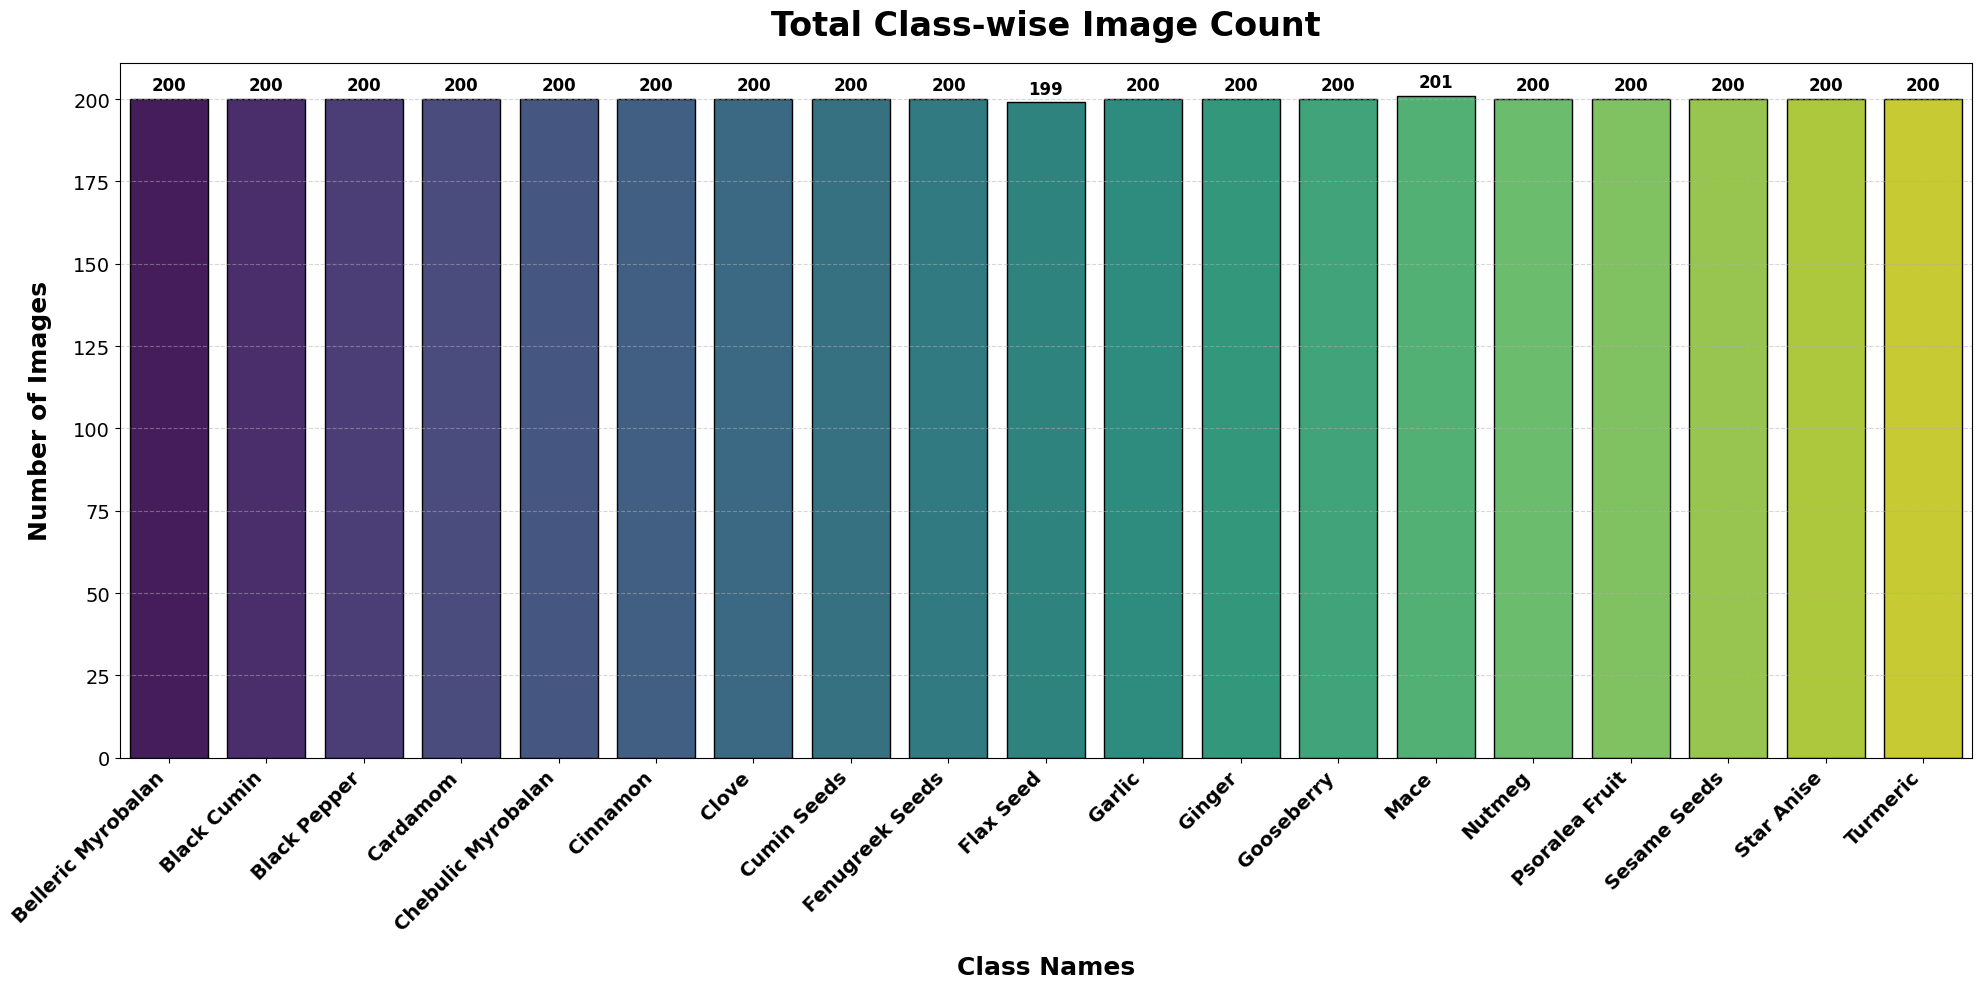

In [ ]:
# ==============================================================================
# DATASET DISTRIBUTION ANALYSIS MODULE
# ==============================================================================
# This script performs a quantitative analysis of the dataset class distribution.
# It validates the data directory, calculates class frequencies, generates a
# summary table, and visualizes the distribution using a high-resolution bar chart.
# ==============================================================================
import os
import time
import gc
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from torchvision.datasets import ImageFolder
from pathlib import Path

# ==============================================================================
# 1. CONFIGURATION AND DATASET INITIALIZATION
# ==============================================================================

# Define input and output directory paths
DATASET_PATH = Path("/content/drive/MyDrive/BDMediHerb/Original Dataset")
OUT_DIR = Path("/content/drive/MyDrive/BDMediHerb/Outputs")

# Ensure the output directory exists
OUT_DIR.mkdir(exist_ok=True, parents=True)

print(f"[INFO] Verifying dataset directory: {DATASET_PATH}")

try:
    # Validate directory existence
    if not DATASET_PATH.exists():
        raise FileNotFoundError(f"Directory not found at specified path: {DATASET_PATH}")

    # Load dataset structure using torchvision ImageFolder
    full_dataset = ImageFolder(root=str(DATASET_PATH))
    print(f"[INFO] Dataset successfully loaded. Total samples: {len(full_dataset)}")
    print(f"[INFO] Number of classes detected: {len(full_dataset.classes)}")

except FileNotFoundError as e:
    print(f"[ERROR] {e}")
    print("[ERROR] Please ensure the dataset decompression (unzip) process completed successfully.")

    # Debugging: List contents of parent directory to assist in troubleshooting
    parent_dir = Path("/content/temp_dataset")
    if parent_dir.exists():
        print(f"[DEBUG] Contents of {parent_dir}: {os.listdir(parent_dir)}")

# ==============================================================================
# 2. STATISTICAL ANALYSIS AND VISUALIZATION UTILITIES
# ==============================================================================

def analyze_dataset_distribution(dataset, title="Dataset Distribution"):
    """
    Analyzes the frequency of samples per class and generates a distribution plot.

    Parameters:
    -----------
    dataset : torchvision.datasets.ImageFolder
        The loaded dataset containing target labels and class mappings.
    title : str
        The title for the generated visualization.
    """

    # Extract targets and class mapping
    targets = dataset.targets
    class_names = dataset.classes

    # Calculate frequency distribution
    counts = pd.Series(targets).value_counts().sort_index()

    # Create a summary DataFrame for tabular representation
    df_dist = pd.DataFrame({
        "Class ID": counts.index,
        "Class Name": [class_names[i] for i in counts.index],
        "Image Count": counts.values
    })

    # Output statistical summary to console
    print(f"\n[REPORT] {title} Table:")
    print(df_dist.to_string(index=False))
    print(f"\n[INFO] Total Sample Count: {df_dist['Image Count'].sum()}")

    # Initialize visualization figure
    plt.figure(figsize=(20, 10))

    # Generate bar plot using Seaborn
    ax = sns.barplot(
        x="Class Name",
        y="Image Count",
        data=df_dist,
        palette="viridis",
        edgecolor='black'
    )

    # Configure chart aesthetics for publication quality
    plt.title(title, fontsize=24, fontweight='bold', pad=20)
    plt.xlabel("Class Names", fontsize=18, fontweight='bold', labelpad=15)
    plt.ylabel("Number of Images", fontsize=18, fontweight='bold', labelpad=15)

    # Configure axis ticks
    plt.xticks(rotation=45, ha='right', fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14)

    # Add gridlines for readability
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Annotate bars with exact counts
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center',
            xytext=(0, 10),
            textcoords='offset points',
            fontsize=12, fontweight='bold', color='black'
        )

    # Finalize layout and save to disk
    plt.tight_layout()
    save_path = OUT_DIR / "Dataset_Distribution.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    print(f"[INFO] Distribution graph saved successfully to: {save_path}")
    plt.show()

# ==============================================================================
# 3. EXECUTION ROUTINE
# ==============================================================================

if 'full_dataset' in locals():
    print("\n[INFO] Initiating class distribution analysis...")
    analyze_dataset_distribution(full_dataset, title="Total Class-wise Image Count")
else:
    print("[WARNING] Dataset object not found. Skipping analysis.")

In [ ]:
# ==============================================================================
# RESEARCH PROJECT: Automated Classification of Bangladeshi Medicinal Fruits/Seeds
# DATASET: BDMediHerb (19 Classes)
# PIPELINE: Sequential Multi-Model Training & Comparative Analysis
# STRATEGY: Stratified Partitioning | Dynamic Resolution | Partial Fine-tuning
# ==============================================================================

# PHASE 0: SYSTEM IMPORTS & ENVIRONMENT SETUP
# ------------------------------------------------------------------------------
import os
import time
import gc
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

# Specialized utility for architectural metadata
try:
    from torchinfo import summary
except ImportError:
    print("[INFO] Installing torchinfo for detailed model analysis...")
    !pip install torchinfo -q
    from torchinfo import summary

# Google Drive synchronization for persistent storage
from google.colab import drive
drive.mount('/content/drive')


# PHASE 1: GLOBAL CONFIGURATIONS & HYPERPARAMETERS
# ------------------------------------------------------------------------------
BASE_DIR = "/content/drive/MyDrive/BDMediHerb/Original Dataset"
PROJECT_ROOT = "/content/drive/MyDrive/BDMediHerb/Outputs"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CONFIG = {
    "batch_size": 32,
    "epochs": 50,
    "lr": 5e-6,
    "num_classes": 19,
    "patience": 8,
    "label_smoothing": 0.3,
    "weight_decay": 1e-2
}

MODEL_LIST = [
    "MobileNet_V3_Large",
    "EfficientNetV2_S",
    "ResNet50",
    "DenseNet121",
    "ViT_B16",
    "Inception_V3",
    "ConvNeXt_Tiny"
]


# PHASE 2: DATA ENGINEERING UTILITIES
# ------------------------------------------------------------------------------
class MapDataset(torch.utils.data.Dataset):
    """Wraps a subset to apply model-specific image augmentations."""
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.dataset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.dataset)

def get_loaders_for_resolution(train_idx, val_idx, test_idx, img_size, full_ds):
    """Generates resolution-aware DataLoaders and Weighted Samplers."""
    train_trans = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    eval_trans = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Re-balancing the training distribution using class weights
    train_labels = np.array(full_ds.targets)[train_idx]
    class_weights = 1. / np.bincount(train_labels)
    sample_weights = np.array([class_weights[t] for t in train_labels])
    sampler = WeightedRandomSampler(torch.DoubleTensor(sample_weights), num_samples=len(sample_weights))

    loaders = {
        'train': DataLoader(MapDataset(Subset(full_ds, train_idx), train_trans), batch_size=CONFIG["batch_size"], sampler=sampler),
        'val': DataLoader(MapDataset(Subset(full_ds, val_idx), eval_trans), batch_size=CONFIG["batch_size"], shuffle=False),
        'test': DataLoader(MapDataset(Subset(full_ds, test_idx), eval_trans), batch_size=CONFIG["batch_size"], shuffle=False)
    }
    return loaders


# PHASE 3: MODEL FACTORY & UNFREEZING STRATEGIES
# ------------------------------------------------------------------------------
def initialize_architecture(name):
    """Configures models with customized heads and selective backbone unfreezing."""
    if name == "MobileNet_V3_Large":
        model = models.mobilenet_v3_large(weights="DEFAULT")
        for p in model.parameters(): p.requires_grad = False
        for p in model.features[13:].parameters(): p.requires_grad = True
        num_ftrs = model.classifier[3].in_features
        model.classifier[3] = nn.Sequential(nn.Linear(num_ftrs, 512), nn.ReLU(), nn.Dropout(0.5), nn.Linear(512, CONFIG["num_classes"]))

    elif name == "EfficientNetV2_S":
        model = models.efficientnet_v2_s(weights="DEFAULT")
        for p in model.parameters(): p.requires_grad = False
        for p in model.features[6:].parameters(): p.requires_grad = True
        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, CONFIG["num_classes"]))

    elif name == "ResNet50":
        model = models.resnet50(weights="DEFAULT")
        for p in model.parameters(): p.requires_grad = False
        for p in model.layer4.parameters(): p.requires_grad = True
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, CONFIG["num_classes"])

    elif name == "DenseNet121":
        model = models.densenet121(weights="DEFAULT")
        for p in model.parameters(): p.requires_grad = False
        for p in model.features.denseblock4.parameters(): p.requires_grad = True
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Linear(num_ftrs, CONFIG["num_classes"])

    elif name == "ViT_B16":
        model = models.vit_b_16(weights="DEFAULT")
        for p in model.parameters(): p.requires_grad = False
        for p in model.encoder.layers[10:].parameters(): p.requires_grad = True
        num_ftrs = model.heads.head.in_features
        model.heads.head = nn.Linear(num_ftrs, CONFIG["num_classes"])


    elif name == "Inception_V3":
        model = models.inception_v3(weights="DEFAULT", aux_logits=True)
        model.aux_logits = False
        model.AuxLogits = None
        for p in model.parameters(): p.requires_grad = False
        for p in model.Mixed_7c.parameters(): p.requires_grad = True
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, CONFIG["num_classes"])



    elif name == "ConvNeXt_Tiny":
        model = models.convnext_tiny(weights="DEFAULT")
        for p in model.parameters(): p.requires_grad = False
        for p in model.features[7].parameters(): p.requires_grad = True
        num_ftrs = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(num_ftrs, CONFIG["num_classes"])

    return model.to(DEVICE)


# PHASE 4: DIAGNOSTIC & ARTIFACT EXPORT FUNCTIONS
# ------------------------------------------------------------------------------
def export_model_summary_csv(model, export_path, img_size):
    """Saves layer-wise architectural metadata for publication methodology."""
    stats = summary(model, input_size=(CONFIG["batch_size"], 3, img_size, img_size), verbose=0)
    summary_list = []
    for layer in stats.summary_list:
        summary_list.append({
            "Layer Name": layer.class_name, "Input Shape": str(layer.input_size),
            "Output Shape": str(layer.output_size), "Parameters": layer.num_params, "Trainable": layer.trainable
        })
    pd.DataFrame(summary_list).to_csv(os.path.join(export_path, "architecture_summary.csv"), index=False)

def run_failure_analysis(model, loader, class_names, export_path, num_visuals=20):
    """Analyzes model errors by saving misclassified images and a detailed CSV taxonomy."""
    model.eval(); error_dir = os.path.join(export_path, "Failure_Analysis")
    os.makedirs(error_dir, exist_ok=True); error_log = []; visual_count = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs_dev = inputs.to(DEVICE); outputs = model(inputs_dev)
            probs = F.softmax(outputs, dim=1); confs, preds = torch.max(probs, 1)
            wrong = (preds.cpu() != labels).nonzero(as_tuple=True)[0]
            for idx in wrong:
                act_nm = class_names[labels[idx].item()]; prd_nm = class_names[preds[idx].item()]
                conf = round(confs[idx].item() * 100, 4)
                error_log.append({"Actual": act_nm, "Predicted": prd_nm, "Confidence (%)": conf})
                if visual_count < num_visuals:
                    img = inputs[idx].numpy().transpose((1, 2, 0))
                    img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
                    plt.figure(); plt.imshow(img); plt.axis('off')
                    plt.title(f"A: {act_nm} | P: {prd_nm}\nConf: {conf}%", color='red')
                    plt.savefig(os.path.join(error_dir, f"fail_{visual_count+1}.png"), bbox_inches='tight'); plt.close(); visual_count += 1
    pd.DataFrame(error_log).to_csv(os.path.join(export_path, "detailed_misclassifications.csv"), index=False)



# PHASE 5: GLOBAL DATA PARTITIONING
# ------------------------------------------------------------------------------
full_ds_raw = datasets.ImageFolder(BASE_DIR)
all_labels = np.array(full_ds_raw.targets)
all_indices = np.arange(len(all_labels))


# Stratified 70:15:15 split logic
tr_val_idx, test_idx = train_test_split(all_indices, test_size=0.15, stratify=all_labels, random_state=42)
train_idx, val_idx = train_test_split(tr_val_idx, test_size=(0.15/0.85), stratify=all_labels[tr_val_idx], random_state=42)
print(f"[INFO] Data Split Complete -> Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")



# PHASE 6: MASTER EXECUTION LOOP (TRAINING & EVALUATION)
# ------------------------------------------------------------------------------
for MODEL_NAME in MODEL_LIST:
    current_res = 299 if MODEL_NAME == "Inception_V3" else 224
    print(f"\n\n{'='*80}\n[JOURNAL PIPELINE] PROCESSING: {MODEL_NAME} | RESOLUTION: {current_res}\n{'='*80}")

    EXPORT_DIR = os.path.join(PROJECT_ROOT, MODEL_NAME)
    os.makedirs(EXPORT_DIR, exist_ok=True)

    # Component Initialization
    loaders = get_loaders_for_resolution(train_idx, val_idx, test_idx, current_res, full_ds_raw)
    model = initialize_architecture(MODEL_NAME)
    export_model_summary_csv(model, EXPORT_DIR, current_res)

    optimizer = optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
    criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG["label_smoothing"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

    history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'inf_ms': [], 'time_sec': [], 'lr': []}
    best_acc, early_stop_counter = 0.0, 0

    print(f"\n{'Epoch':<8} | {'Tr. Loss':<10} | {'Tr. Acc':<10} | {'Val Loss':<10} | {'Val Acc':<10} | {'Inference':<12} | {'Time'}")
    print("-" * 105)

    # --- START OF CORE RESEARCH LOOP ---
    for epoch in range(CONFIG["epochs"]):
        epoch_start = time.time()

        # 1. Training Phase
        model.train(); tr_loss, tr_correct = 0.0, 0
        for imgs, lbls in loaders['train']:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad(); out = model(imgs); loss = criterion(out, lbls)
            loss.backward(); optimizer.step()
            tr_loss += loss.item() * imgs.size(0); tr_correct += (out.max(1)[1] == lbls).sum().item()

        # 2. Validation Phase
        model.eval(); v_loss, v_correct, latencies = 0.0, 0, []
        with torch.no_grad():
            for imgs, lbls in loaders['val']:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                tic = time.time(); out = model(imgs); latencies.append((time.time()-tic)/imgs.size(0))
                v_loss += criterion(out, lbls).item() * imgs.size(0); v_correct += (out.max(1)[1] == lbls).sum().item()

        # 3. Scientific Metrics Calculation (4-Decimal Precision)
        cur_t_acc = round(tr_correct / len(train_idx), 4); cur_v_acc = round(v_correct / len(val_idx), 4)
        cur_t_loss = round(tr_loss / len(train_idx), 4); cur_v_loss = round(v_loss / len(val_idx), 4)
        cur_inf_ms = round(np.mean(latencies) * 1000, 4); cur_time = round(time.time() - epoch_start, 2)

        history['epoch'].append(epoch + 1); history['train_loss'].append(cur_t_loss)
        history['train_acc'].append(cur_t_acc); history['val_loss'].append(cur_v_loss)
        history['val_acc'].append(cur_v_acc); history['inf_ms'].append(cur_inf_ms)
        history['time_sec'].append(cur_time); history['lr'].append(optimizer.param_groups[0]['lr'])

        # Professional Log Output
        print(f"{epoch+1:<8} | {cur_t_loss:<10.4f} | {cur_t_acc:<10.4f} | {cur_v_loss:<10.4f} | {cur_v_acc:<10.4f} | {cur_inf_ms:<10.4f} ms | {cur_time:<8}s")

        # Early Stopping Logic & Model Archiving
        if cur_v_acc > best_acc:
            best_acc = cur_v_acc; torch.save(model.state_dict(), os.path.join(EXPORT_DIR, "best_model.pth")); early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= CONFIG["patience"]: break
        scheduler.step(cur_v_acc)
    # --- END OF CORE RESEARCH LOOP ---

    # PHASE 7: POST-TRAINING RESEARCH VISUALIZATION
    # ------------------------------------------------------------------------------
    print(f"[POST] Finalizing Artifacts for {MODEL_NAME}...")
    model.load_state_dict(torch.load(os.path.join(EXPORT_DIR, "best_model.pth")))
    model.eval(); y_true, y_pred, y_score = [], [], []

    with torch.no_grad():
        for imgs, lbls in loaders['test']:
            imgs = imgs.to(DEVICE); outputs = model(imgs)
            y_true.extend(lbls.numpy()); y_pred.extend(outputs.max(1)[1].cpu().numpy()); y_score.extend(F.softmax(outputs, dim=1).cpu().numpy())

    # 1. Classification Report & Confusion Matrix
    report = classification_report(y_true, y_pred, target_names=full_ds_raw.classes, output_dict=True, digits=4)
    pd.DataFrame(report).transpose().to_csv(os.path.join(EXPORT_DIR, "final_metrics_report.csv"), float_format='%.4f')


    # Confusion Matrix
    plt.figure(figsize=(16, 14)); cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=full_ds_raw.classes, yticklabels=full_ds_raw.classes)
    plt.title(f'Confusion Matrix {MODEL_NAME}', fontsize=18, fontweight='bold')
    plt.ylabel('Ground Truth'); plt.xlabel('Predicted Class'); plt.xticks(rotation=45, ha='right'); plt.tight_layout()
    plt.savefig(os.path.join(EXPORT_DIR, "confusion_matrix.png"), dpi=300); plt.close()


    # 2. Multi-class ROC-AUC Analysis
    y_true_bin = label_binarize(y_true, classes=range(CONFIG["num_classes"]))
    plt.figure(figsize=(12, 10))
    for i in range(CONFIG["num_classes"]):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], np.array(y_score)[:, i])
        plt.plot(fpr, tpr, label=f'{full_ds_raw.classes[i]} (AUC={auc(fpr, tpr):.4f})')
    plt.plot([0, 1], [0, 1], 'k--'); plt.legend(bbox_to_anchor=(1.05, 1)); plt.title(f'Multi-class ROC: {MODEL_NAME}'); plt.savefig(os.path.join(EXPORT_DIR, "roc_auc.png"), dpi=300, bbox_inches='tight'); plt.close()

    # 3. F1-Score Chart & Learning Curves
    f1_vals = [report[cls]['f1-score'] * 100 for cls in full_ds_raw.classes]
    plt.figure(figsize=(12, 6)); ax = sns.barplot(x=full_ds_raw.classes, y=f1_vals, palette="viridis")
    for i, v in enumerate(f1_vals): ax.text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')
    plt.xticks(rotation=45); plt.savefig(os.path.join(EXPORT_DIR, "f1_score_performance.png"), dpi=300, bbox_inches='tight'); plt.close()

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history['train_acc'], label='Tr'); plt.plot(history['val_acc'], label='Val'); plt.title('Accuracy'); plt.legend()
    plt.subplot(1, 2, 2); plt.plot(history['train_loss'], label='Tr'); plt.plot(history['val_loss'], label='Val'); plt.title('Loss'); plt.legend()
    plt.savefig(os.path.join(EXPORT_DIR, "learning_curves.png"), dpi=300); plt.close()

    # 4. Failure Analysis & Metadata Export
    run_failure_analysis(model, loaders['test'], full_ds_raw.classes, EXPORT_DIR)
    pd.DataFrame(history).to_csv(os.path.join(EXPORT_DIR, "training_history.csv"), index=False)

    # Garbage Collection & Memory Flush
    del model, optimizer, loaders; gc.collect(); torch.cuda.empty_cache()
    print(f"✔ Pipeline finished for {MODEL_NAME}. Data archived.\n")

print("\n" + "="*80 + "\n[FINAL] COMPREHENSIVE RESEARCH PIPELINE COMPLETED SUCCESSFULLY\n" + "="*80)

[INFO] Installing torchinfo for detailed model analysis...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Data Split Complete -> Train: 2660 | Val: 570 | Test: 570


[JOURNAL PIPELINE] PROCESSING: MobileNet_V3_Large | RESOLUTION: 224
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 98.6MB/s]



Epoch    | Tr. Loss   | Tr. Acc    | Val Loss   | Val Acc    | Inference    | Time
---------------------------------------------------------------------------------------------------------
1        | 2.9299     | 0.0853     | 2.9160     | 0.1211     | 0.2969     ms | 1345.08 s
2        | 2.8898     | 0.1883     | 2.8611     | 0.4035     | 0.2477     ms | 439.23  s
3        | 2.8427     | 0.3323     | 2.8007     | 0.6333     | 0.2365     ms | 206.75  s
4        | 2.7864     | 0.4992     | 2.7273     | 0.8105     | 0.2514     ms | 115.3   s
5        | 2.7083     | 0.6594     | 2.6338     | 0.8842     | 0.2555     ms | 93.62   s
6        | 2.6140     | 0.7511     | 2.5074     | 0.9193     | 0.2633     ms | 81.43   s
7        | 2.4877     | 0.8237     | 2.3526     | 0.9456     | 0.2568     ms | 75.86   s
8        | 2.3269     | 0.8707     | 2.1684     | 0.9596     | 0.2404     ms | 73.63   s
9        | 2.1646     | 0.8876     | 1.9858     | 0.9684     | 0.2635     ms | 74.43   s
10       

/tmp/ipykernel_6197/1919960654.py:323: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plt.figure(figsize=(12, 6)); ax = sns.barplot(x=full_ds_raw.classes, y=f1_vals, palette="viridis")


✔ Pipeline finished for MobileNet_V3_Large. Data archived.



[JOURNAL PIPELINE] PROCESSING: EfficientNetV2_S | RESOLUTION: 224
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


...

✔ Pipeline finished for Inception_V3. Data archived.



[JOURNAL PIPELINE] PROCESSING: ConvNeXt_Tiny | RESOLUTION: 224
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 177MB/s]



Epoch    | Tr. Loss   | Tr. Acc    | Val Loss   | Val Acc    | Inference    | Time
---------------------------------------------------------------------------------------------------------
1        | 2.8533     | 0.1940     | 2.7102     | 0.3281     | 4.2968     ms | 89.81   s
2        | 2.5971     | 0.4605     | 2.4319     | 0.6421     | 0.2172     ms | 85.26   s
3        | 2.3301     | 0.7534     | 2.1633     | 0.8965     | 0.2206     ms | 85.47   s
4        | 2.0934     | 0.8831     | 1.9340     | 0.9491     | 0.2083     ms | 87.58   s
5        | 1.9081     | 0.9293     | 1.7644     | 0.9719     | 0.2092     ms | 87.28   s
6        | 1.7842     | 0.9538     | 1.6591     | 0.9842     | 0.2312     ms | 85.64   s
7        | 1.6922     | 0.9662     | 1.5958     | 0.9842     | 0.2186     ms | 86.37   s
8        | 1.6502     | 0.9647     | 1.5588     | 0.9842     | 0.2117     ms | 83.44   s
9        | 1.6107     | 0.9737     | 1.5371     | 0.9842     | 0.2033     ms | 85.88   s
10       

/tmp/ipykernel_6197/1919960654.py:323: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plt.figure(figsize=(12, 6)); ax = sns.barplot(x=full_ds_raw.classes, y=f1_vals, palette="viridis")


✔ Pipeline finished for ConvNeXt_Tiny. Data archived.


[FINAL] COMPREHENSIVE RESEARCH PIPELINE COMPLETED SUCCESSFULLY


In [ ]:
# ==============================================================================
# PHASE 9: GLOBAL RESEARCH COMPARATIVE ANALYSIS & MASTER TABLE GENERATION
# This module aggregates metrics for both Base Architectures and the Hybrid Model.
# ==============================================================================

import os
import pandas as pd
import numpy as np

print("\n" + "="*100)
print(f"{'[SYSTEM] GENERATING GLOBAL MASTER COMPARISON TABLE (TEST DATA)':^100}")
print("="*100)

master_summary = []

# List of all directories to check (Base Models + Proposed Hybrid)
# We dynamically add the Hybrid folder to the search list
MODELS_TO_COMPARE = MODEL_LIST + ["Hybrid_TripleStream"]

for name in MODELS_TO_COMPARE:
    model_folder = os.path.join(PROJECT_ROOT, name)

    # Adaptive file naming for Hybrid vs Base models
    if name == "Hybrid_TripleStream":
        report_file = os.path.join(model_folder, "hybrid_final_metrics_report.csv")
        history_file = os.path.join(model_folder, "hybrid_training_history.csv")
        display_name = "Proposed Hybrid (Triple-Stream)"
    else:
        report_file = os.path.join(model_folder, "final_metrics_report.csv")
        history_file = os.path.join(model_folder, "training_history.csv")
        display_name = name

    if os.path.exists(report_file) and os.path.exists(history_file):
        try:
            # 1. Load the Classification Report
            df_report = pd.read_csv(report_file, index_col=0)

            # 2. Load the Training History for computational metrics
            df_history = pd.read_csv(history_file)

            # 3. Extract Core Scientific Metrics
            # Accuracy is pulled from the 'accuracy' row (F1-score column as per user logic)
            test_accuracy = df_report.loc['accuracy', 'f1-score'] * 100
            macro_f1 = df_report.loc['macro avg', 'f1-score'] * 100
            weighted_f1 = df_report.loc['weighted avg', 'f1-score'] * 100

            # 4. Extract Computational Complexity Metrics
            avg_inf_ms = df_history['inf_ms'].mean()
            total_train_min = df_history['time_sec'].sum() / 60
            total_epochs = df_history['epoch'].max()

            master_summary.append({
                "Model Architecture": display_name,
                "Test Accuracy (%)": f"{test_accuracy:.2f}%",
                "Macro F1-Score (%)": f"{macro_f1:.2f}%",
                "Weighted F1 (%)": f"{weighted_f1:.2f}%",
                "Inference Latency (ms)": f"{avg_inf_ms:.4f}",
                "Training Time (Min)": f"{total_train_min:.2f}",
                "Epochs": int(total_epochs)
            })
        except Exception as e:
            print(f"[WARNING] Error processing metrics for {name}: {e}")

if master_summary:
    # Generate the final Master DataFrame
    master_df = pd.DataFrame(master_summary)

    # Sort models by Test Accuracy for better visual comparison in paper
    master_df['Sort_Acc'] = master_df['Test Accuracy (%)'].str.replace('%','').astype(float)
    master_df = master_df.sort_values('Sort_Acc', ascending=False).drop(columns=['Sort_Acc'])

    # Export to CSV for Manuscript inclusion
    master_csv_path = os.path.join(PROJECT_ROOT, "Final_Global_Comparison_Table.csv")
    master_df.to_csv(master_csv_path, index=False)

    # Professional formatted console output
    print("\n" + "*"*120)
    print(f"{'BDMEDIHERB COMPREHENSIVE STUDY: MASTER PERFORMANCE BENCHMARK':^120}")
    print("*"*120)
    print(master_df.to_string(index=False))
    print("*"*120)
    print(f"\n[SUCCESS] Global Comparison Table archived at: {master_csv_path}")

    # Optional: Display the best performing model summary
    winner = master_df.iloc[0]
    print(f"\n[INSIGHT] Best Performing Model: {winner['Model Architecture']} with {winner['Test Accuracy (%)']} accuracy.")
else:
    print("[ERROR] No metric files found. Ensure evaluation phases were executed for all models.")


                   [SYSTEM] GENERATING GLOBAL MASTER COMPARISON TABLE (TEST DATA)                   

************************************************************************************************************************
                              BDMEDIHERB COMPREHENSIVE STUDY: MASTER PERFORMANCE BENCHMARK                              
************************************************************************************************************************
Model Architecture Test Accuracy (%) Macro F1-Score (%) Weighted F1 (%) Inference Latency (ms) Training Time (Min)  Epochs
          ResNet50            98.77%             98.77%          98.77%                 0.2319               28.90      20
MobileNet_V3_Large            98.60%             98.60%          98.60%                 0.2563               61.25      25
           ViT_B16            98.60%             98.60%          98.60%                 0.2120               25.91      13
     ConvNeXt_Tiny            98.60%      

In [ ]:
# ==============================================================================
# PHASE 8: SYSTEM IMPORTS & ENVIRONMENT SETUP
# ==============================================================================
import os
import time
import gc
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from google.colab import drive
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# Mount Google Drive
drive.mount('/content/drive')

# Device Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Global Hyperparameters
CONFIG = {
    "batch_size": 32,
    "epochs": 50,
    "lr": 5e-6,
    "num_classes": 19,
    "patience": 8,
    "label_smoothing": 0.1,
    "weight_decay": 1e-2
}

# Project Paths
BASE_DIR = "/content/drive/MyDrive/BDMediHerb/Original Dataset"
PROJECT_ROOT = "/content/drive/MyDrive/BDMediHerb/Outputs"
BEST_3_NAMES = ["MobileNet_V3_Large", "ResNet50", "ViT_B16"]

# ==============================================================================
# PHASE 1: UTILITY CLASSES & FUNCTIONS
# ==============================================================================

class MapDataset(torch.utils.data.Dataset):
    """Wraps a subset to apply transforms dynamically."""
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.dataset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.dataset)

def initialize_architecture(name):
    """Initializes backbone architectures to EXACTLY match the saved weights."""
    if name == "MobileNet_V3_Large":
        model = models.mobilenet_v3_large(weights="DEFAULT")
        num_ftrs = model.classifier[3].in_features
        # This matches your original training Phase 3 structure
        model.classifier[3] = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, CONFIG["num_classes"])
        )
    elif name == "ResNet50":
        model = models.resnet50(weights="DEFAULT")
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, CONFIG["num_classes"])
    elif name == "ViT_B16":
        model = models.vit_b_16(weights="DEFAULT")
        num_ftrs = model.heads.head.in_features
        model.heads.head = nn.Linear(num_ftrs, CONFIG["num_classes"])
    return model

class FocalLoss(nn.Module):
    """Focal Loss to handle hard-to-classify samples at terminal accuracy stages."""
    def __init__(self, alpha=1, gamma=2, label_smoothing=0.05):
        super(FocalLoss, self).__init__()
        self.alpha = alpha; self.gamma = gamma; self.label_smoothing = label_smoothing
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

def run_failure_analysis(model, loader, class_names, export_path):
    """Exports misclassified images and error logs for research audit."""
    model.eval()
    error_dir = os.path.join(export_path, "Failure_Analysis")
    os.makedirs(error_dir, exist_ok=True)
    error_log = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            preds = outputs.max(1)[1].cpu()
            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    error_log.append({
                        "Actual": class_names[labels[i]],
                        "Predicted": class_names[preds[i]]
                    })

    # Save the log to the export_path
    pd.DataFrame(error_log).to_csv(os.path.join(export_path, "misclassifications.csv"), index=False)

    # FIX: Changed export_dir to error_dir
    print(f"[INFO] Failure analysis report saved to {error_dir}")

# ==============================================================================
# PHASE 2: DATA RE-LOADING & STRATIFIED PARTITIONING
# ==============================================================================

print("\n" + "-"*30 + "\n[INFO] Loading Dataset and Partitioning...\n" + "-"*30)
hybrid_ds_raw = datasets.ImageFolder(BASE_DIR)
hybrid_labels = np.array(hybrid_ds_raw.targets)
hybrid_indices = np.arange(len(hybrid_labels))

# Stratified Split 70:15:15
idx_train_val_hybrid, hybrid_test_idx = train_test_split(
    hybrid_indices, test_size=0.15, stratify=hybrid_labels, random_state=42
)
idx_train_hybrid, hybrid_val_idx = train_test_split(
    idx_train_val_hybrid, test_size=(0.15/0.85), stratify=hybrid_labels[idx_train_val_hybrid], random_state=42
)

def get_hybrid_loaders(train_idx, val_idx, test_idx, img_size, full_ds):
    """Generates resolution-aware loaders with heavy training augmentations."""
    train_trans = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(20),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    eval_trans = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return {
        'train': DataLoader(MapDataset(Subset(full_ds, train_idx), train_trans), batch_size=CONFIG["batch_size"], shuffle=True),
        'val': DataLoader(MapDataset(Subset(full_ds, val_idx), eval_trans), batch_size=CONFIG["batch_size"], shuffle=False),
        'test': DataLoader(MapDataset(Subset(full_ds, test_idx), eval_trans), batch_size=CONFIG["batch_size"], shuffle=False)
    }

# Initialize Loaders
HYBRID_RES = 224
hybrid_loaders = get_hybrid_loaders(idx_train_hybrid, hybrid_val_idx, hybrid_test_idx, HYBRID_RES, hybrid_ds_raw)

# ==============================================================================
# PHASE 3: COMPONENT ARCHITECTURE & ENSEMBLE CORE
# ==============================================================================

class FeatureExtractor(nn.Module):
    """Wraps backbones and loads individual weights, stripping classification heads."""
    def __init__(self, model_name):
        super(FeatureExtractor, self).__init__()
        base_model = initialize_architecture(model_name)
        weights_path = os.path.join(PROJECT_ROOT, model_name, "best_model.pth")
        base_model.load_state_dict(torch.load(weights_path, map_location=DEVICE))

        if "ViT" in model_name:
            self.feat_dim = base_model.heads.head.in_features
            base_model.heads = nn.Identity()
        elif "ResNet" in model_name:
            self.feat_dim = base_model.fc.in_features
            base_model.fc = nn.Identity()
        elif "MobileNet" in model_name:
            self.feat_dim = base_model.classifier[0].in_features
            base_model.classifier = nn.Identity()
        self.backbone = base_model

    def forward(self, x):
        x = self.backbone(x)
        if len(x.shape) > 2: x = torch.flatten(x, 1)
        return x

class EnsembleStackingNet(nn.Module):
    """Meta-learner that learns to weight opinions from three independent backbones."""
    def __init__(self, model_names, num_classes=19):
        super(EnsembleStackingNet, self).__init__()
        self.stream1 = FeatureExtractor(model_names[0])
        self.stream2 = FeatureExtractor(model_names[1])
        self.stream3 = FeatureExtractor(model_names[2])
        self.head1 = nn.Linear(self.stream1.feat_dim, num_classes)
        self.head2 = nn.Linear(self.stream2.feat_dim, num_classes)
        self.head3 = nn.Linear(self.stream3.feat_dim, num_classes)
        self.meta_learner = nn.Sequential(
            nn.Linear(num_classes * 3, 256),
            nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        f1 = self.stream1(x); f2 = self.stream2(x); f3 = self.stream3(x)
        out1 = self.head1(f1); out2 = self.head2(f2); out3 = self.head3(f3)
        stacked_logits = torch.cat([out1, out2, out3], dim=-1)
        return self.meta_learner(stacked_logits)


# ==============================================================================
# PHASE 4: TRAINING EXECUTION
# ==============================================================================

model_hybrid = EnsembleStackingNet(BEST_3_NAMES).to(DEVICE)
optimizer = optim.AdamW([
    {'params': model_hybrid.stream1.parameters(), 'lr': 1e-6},
    {'params': model_hybrid.stream2.parameters(), 'lr': 1e-6},
    {'params': model_hybrid.stream3.parameters(), 'lr': 1e-6},
    {'params': model_hybrid.head1.parameters(), 'lr': 1e-4},
    {'params': model_hybrid.head2.parameters(), 'lr': 1e-4},
    {'params': model_hybrid.head3.parameters(), 'lr': 1e-4},
    {'params': model_hybrid.meta_learner.parameters(), 'lr': 1e-4}
], weight_decay=0.01)

criterion = FocalLoss(gamma=2, label_smoothing=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)


# ------------------------------------------------------------------------------
# 5. EXECUTION: HIGH-PRECISION TRAINING & LATENCY TRACKING
# ------------------------------------------------------------------------------
best_hyb_acc = 0.0
early_stop_counter = 0
CONFIG["patience"] = 8

# Archive indices lengths for precise accuracy calculation
len_train = len(idx_train_hybrid)
len_val = len(hybrid_val_idx)

# Paths for saving
EXPORT_DIR_HYB = os.path.join(PROJECT_ROOT, "Hybrid_TripleStream")
os.makedirs(EXPORT_DIR_HYB, exist_ok=True)
local_path = "temp_best_hybrid.pth"
drive_path = os.path.join(EXPORT_DIR_HYB, "best_hybrid_model.pth")

# Initialize history dictionary before starting the loop
history_hyb = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'inf_ms': [], 'time_sec': [], 'lr': []}

print(f"\n{'Epoch':<8} | {'Tr. Loss':<10} | {'Tr. Acc':<10} | {'Val Loss':<10} | {'Val Acc':<10} | {'Inference':<12} | {'Time'}")
print("-" * 105)


# Now your existing loop starts...
for epoch in range(CONFIG["epochs"]):
    epoch_start = time.time()

    # --- TRAINING PHASE ---
    model_hybrid.train()
    tr_loss, tr_correct = 0.0, 0
    for imgs, lbls in hybrid_loaders['train']:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out = model_hybrid(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * imgs.size(0)
        tr_correct += (out.max(1)[1] == lbls).sum().item()

    # --- VALIDATION PHASE ---
    model_hybrid.eval()
    v_loss, v_correct, latencies = 0.0, 0, []
    with torch.no_grad():
        for imgs, lbls in hybrid_loaders['val']:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            tic = time.time()
            out = model_hybrid(imgs)
            latencies.append((time.time() - tic) / imgs.size(0))
            v_loss += criterion(out, lbls).item() * imgs.size(0)
            v_correct += (out.max(1)[1] == lbls).sum().item()

    # --- METRICS CALCULATION ---
    cur_t_acc = round(tr_correct / len_train, 4)
    cur_v_acc = round(v_correct / len_val, 4)
    cur_t_loss = round(tr_loss / len_train, 4)
    cur_v_loss = round(v_loss / len_val, 4)
    cur_inf_ms = round(np.mean(latencies) * 1000, 4)
    cur_time = round(time.time() - epoch_start, 2)

    # Log results
    history_hyb['epoch'].append(epoch + 1)
    history_hyb['train_loss'].append(cur_t_loss); history_hyb['train_acc'].append(cur_t_acc)
    history_hyb['val_loss'].append(cur_v_loss); history_hyb['val_acc'].append(cur_v_acc)
    history_hyb['inf_ms'].append(cur_inf_ms); history_hyb['time_sec'].append(cur_time)
    history_hyb['lr'].append(optimizer.param_groups[0]['lr'])

    print(f"{epoch+1:<8} | {cur_t_loss:<10.4f} | {cur_t_acc:<10.4f} | {cur_v_loss:<10.4f} | {cur_v_acc:<10.4f} | {cur_inf_ms:<10.4f} ms | {cur_time:<8}s")

    # --- [CRITICAL] IMPROVED SAVING & EARLY STOPPING LOGIC ---
    if cur_v_acc > best_hyb_acc:
        best_hyb_acc = cur_v_acc
        torch.save(model_hybrid.state_dict(), local_path)
        torch.save(model_hybrid.state_dict(), drive_path)
        print(f" ---> [SAVED] Model improved to {best_hyb_acc:.4f}. Checkpoint synced.")
        early_stop_counter = 0
    else:
        # Counter will only increase if accuracy is equal to or less than the best
        early_stop_counter += 1
        if early_stop_counter >= CONFIG["patience"]:
            print(f"\n[INFO] Early stopping triggered at epoch {epoch+1}")
            break

    scheduler.step()

# --- FINAL PERSISTENT LOGGING ---
pd.DataFrame(history_hyb).to_csv(os.path.join(EXPORT_DIR_HYB, "hybrid_training_history.csv"), index=False)
print(f"\n[FINISH] Hybrid Model Pipeline Successfully Completed.")
print(f"[RESULT] Peak Hybrid Validation Accuracy: {best_hyb_acc:.4f}")

# Memory management
del model_hybrid, optimizer; gc.collect(); torch.cuda.empty_cache()



# ==============================================================================
# PHASE 8: COMPREHENSIVE EVALUATION FOR PROPOSED HYBRID MODEL
# Artifacts: Confusion Matrix, Learning Curves, ROC-AUC, and Failure Analysis
# ==============================================================================

print("\n" + "="*80)
print("[INFO] Finalizing Research Artifacts for the Hybrid Model...")
print("="*80)


# ==============================================================================
# PHASE 5: COMPREHENSIVE EVALUATION (4-PASS TTA)
# ==============================================================================

print("\n" + "="*80 + "\n[INFO] Starting Multi-Pass Evaluation...\n" + "="*80)
eval_model = EnsembleStackingNet(BEST_3_NAMES).to(DEVICE)
if os.path.exists("temp_best_hybrid.pth"): eval_model.load_state_dict(torch.load("temp_best_hybrid.pth"))
eval_model.eval(); y_true, y_pred, y_score = [], [], []

with torch.no_grad():
    for imgs, lbls in hybrid_loaders['test']:
        imgs = imgs.to(DEVICE)
        # 4-Pass TTA
        o1 = eval_model(imgs)
        o2 = eval_model(torch.flip(imgs, dims=[3]))
        o3 = eval_model(torch.flip(imgs, dims=[2]))
        o4 = eval_model(torch.flip(imgs, dims=[2, 3]))
        averaged_logits = (o1 + o2 + o3 + o4) / 4
        probabilities = F.softmax(averaged_logits, dim=1); _, preds = torch.max(averaged_logits, 1)
        y_true.extend(lbls.numpy()); y_pred.extend(preds.cpu().numpy()); y_score.extend(probabilities.cpu().numpy())


# 9. CLASSIFICATION REPORT & METRICS EXPORT
# ------------------------------------------------------------------------------
report_hyb = classification_report(y_true, y_pred, target_names=hybrid_ds_raw.classes, output_dict=True, digits=4)
df_report_hyb = pd.DataFrame(report_hyb).transpose()
df_report_hyb.to_csv(os.path.join(EXPORT_DIR_HYB, "hybrid_final_metrics_report.csv"), float_format='%.4f')

print("\n[RESULT] Hybrid Model Test Accuracy: ", round(report_hyb['accuracy'] * 100, 2), "%")

# 10. CONFUSION MATRIX VISUALIZATION (HIGH RESOLUTION)
# ------------------------------------------------------------------------------

plt.figure(figsize=(18, 15))
cm_hyb = confusion_matrix(y_true, y_pred)
sns.heatmap(cm_hyb, annot=True, fmt='d', cmap='Greens',
            xticklabels=hybrid_ds_raw.classes, yticklabels=hybrid_ds_raw.classes)

plt.title('Confusion Matrix: Proposed Triple-Stream Hybrid', fontsize=20, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=14); plt.xlabel('Predicted Class', fontsize=14)
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig(os.path.join(EXPORT_DIR_HYB, "hybrid_confusion_matrix.png"), dpi=400)
plt.close()

# 11. MULTI-CLASS ROC-AUC ANALYSIS
# ------------------------------------------------------------------------------
y_true_bin = label_binarize(y_true, classes=range(CONFIG["num_classes"]))
plt.figure(figsize=(12, 10))
for i in range(CONFIG["num_classes"]):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], np.array(y_score)[:, i])
    plt.plot(fpr, tpr, label=f'{hybrid_ds_raw.classes[i]} (AUC={auc(fpr, tpr):.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.title('Multi-class ROC: Hybrid Model', fontsize=16)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.savefig(os.path.join(EXPORT_DIR_HYB, "hybrid_roc_auc.png"), dpi=300, bbox_inches='tight')
plt.close()

# 12. LEARNING CURVES (FROM SAVED LOGS)
# ------------------------------------------------------------------------------

# Read the CSV log we saved in Phase 13
df_hist_hyb = pd.read_csv(os.path.join(EXPORT_DIR_HYB, "hybrid_training_history.csv"))

plt.figure(figsize=(16, 6))
# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(df_hist_hyb['train_acc'], label='Training Acc', marker='o', alpha=0.7)
plt.plot(df_hist_hyb['val_acc'], label='Validation Acc', marker='s', alpha=0.7)
plt.title('Hybrid Model: Accuracy Curve', fontweight='bold'); plt.legend(); plt.grid(True)

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(df_hist_hyb['train_loss'], label='Training Loss', marker='o', alpha=0.7)
plt.plot(df_hist_hyb['val_loss'], label='Validation Loss', marker='s', alpha=0.7)
plt.title('Hybrid Model: Loss Curve', fontweight='bold'); plt.legend(); plt.grid(True)

plt.savefig(os.path.join(EXPORT_DIR_HYB, "hybrid_learning_curves.png"), dpi=300)
plt.close()

# 13. HYBRID FAILURE ANALYSIS (IMAGE SAMPLES)
# ------------------------------------------------------------------------------
run_failure_analysis(eval_model, hybrid_loaders['test'], hybrid_ds_raw.classes, EXPORT_DIR_HYB)

print(f"\n[SUCCESS] All Hybrid Evaluation Artifacts Saved to: {EXPORT_DIR_HYB}")

Mounted at /content/drive

------------------------------
[INFO] Loading Dataset and Partitioning...
------------------------------
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 109MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 190MB/s]



Epoch    | Tr. Loss   | Tr. Acc    | Val Loss   | Val Acc    | Inference    | Time
---------------------------------------------------------------------------------------------------------
1        | 1.2766     | 0.7853     | 0.4484     | 0.9982     | 0.8096     ms | 1641.89 s
 ---> [SAVED] Model improved to 0.9982. Checkpoint synced.
2        | 0.3674     | 0.9921     | 0.1843     | 1.0000     | 0.7841     ms | 236.96  s
 ---> [SAVED] Model improved to 1.0000. Checkpoint synced.
3        | 0.1952     | 0.9944     | 0.1162     | 1.0000     | 0.7653     ms | 245.53  s
4        | 0.1329     | 0.9970     | 0.0841     | 1.0000     | 0.7552     ms | 234.22  s
5        | 0.1056     | 0.9962     | 0.0690     | 1.0000     | 0.7120     ms | 227.03  s
6        | 0.0935     | 0.9959     | 0.0609     | 1.0000     | 0.6632     ms | 220.16  s
7        | 0.0820     | 0.9970     | 0.0568     | 1.0000     | 0.7451     ms | 219.99  s
8        | 0.0787     | 0.9959     | 0.0508     | 1.0000     | 0.7320

In [ ]:
# ==============================================================================
# PHASE 9: GLOBAL RESEARCH MASTER COMPARISON TABLE
# Features: 7 Base Models + 1 Proposed Hybrid | Accuracy & Latency Benchmarking
# ==============================================================================

import os
import pandas as pd
import numpy as np

# 1. PROJECT PATHS
PROJECT_ROOT = "/content/drive/MyDrive/BDMediHerb/Outputs"

# 2. UPDATED MODEL LIST (As provided by you)
BASE_MODELS = [
    "MobileNet_V3_Large",
    "EfficientNetV2_S",
    "ResNet50",
    "DenseNet121",
    "ViT_B16",
    "Inception_V3",
    "ConvNeXt_Tiny"
]
PROPOSED_HYBRID = "Hybrid_TripleStream"
ALL_MODELS_LIST = BASE_MODELS + [PROPOSED_HYBRID]

print("\n" + "="*125)
print(f"{'BDMEDIHERB COMPREHENSIVE STUDY: MASTER PERFORMANCE BENCHMARK':^125}")
print("="*125)

master_summary = []

for model in ALL_MODELS_LIST:
    folder_path = os.path.join(PROJECT_ROOT, model)

    # Adaptive file naming for Hybrid vs Base models
    if model == PROPOSED_HYBRID:
        report_file = os.path.join(folder_path, "hybrid_final_metrics_report.csv")
        history_file = os.path.join(folder_path, "hybrid_training_history.csv")
        display_label = "Proposed Hybrid (Triple-Stream)"
    else:
        report_file = os.path.join(folder_path, "final_metrics_report.csv")
        history_file = os.path.join(folder_path, "training_history.csv")
        display_label = model

    # Check for file existence
    if os.path.exists(report_file) and os.path.exists(history_file):
        try:
            # Load Metrics
            df_rep = pd.read_csv(report_file, index_col=0)
            df_hist = pd.read_csv(history_file)

            # Scientific Metrics Extraction
            acc = df_rep.loc['accuracy', 'f1-score'] * 100
            macro_f1 = df_rep.loc['macro avg', 'f1-score'] * 100
            weighted_f1 = df_rep.loc['weighted avg', 'f1-score'] * 100

            # Computational Performance
            latency = df_hist['inf_ms'].mean()
            train_min = df_hist['time_sec'].sum() / 60
            epochs = df_hist['epoch'].max()

            master_summary.append({
                "Model Architecture": display_label,
                "Test Accuracy (%)": acc,
                "Macro F1-Score (%)": macro_f1,
                "Weighted F1-Score (%)": weighted_f1,
                "Latency (ms/img)": latency,
                "Training Time (Min)": train_min,
                "Total Epochs": int(epochs)
            })
        except Exception as e:
            print(f"[ERR] Failed to process {model}: {e}")
    else:
        # Diagnostic message for missing folders/files
        missing_files = []
        if not os.path.exists(report_file): missing_files.append("Metrics Report")
        if not os.path.exists(history_file): missing_files.append("History Log")
        print(f"[MISSING] {model:<20} -> {', '.join(missing_files)} not found.")

# 3. DATAFRAME GENERATION & EXPORT
if master_summary:
    master_df = pd.DataFrame(master_summary)

    # Sort by Accuracy (Highest to Lowest)
    master_df = master_df.sort_values('Test Accuracy (%)', ascending=False)

    # Professional Formatting for Console Display
    styled_df = master_df.copy()
    styled_df['Test Accuracy (%)'] = styled_df['Test Accuracy (%)'].map("{:.2f}%".format)
    styled_df['Macro F1-Score (%)'] = styled_df['Macro F1-Score (%)'].map("{:.2f}%".format)
    styled_df['Weighted F1-Score (%)'] = styled_df['Weighted F1-Score (%)'].map("{:.2f}%".format)
    styled_df['Latency (ms/img)'] = styled_df['Latency (ms/img)'].map("{:.4f}".format)
    styled_df['Training Time (Min)'] = styled_df['Training Time (Min)'].map("{:.2f}".format)

    print("\n" + "*"*125)
    print(f"{'GLOBAL RESEARCH RESULTS: COMPARATIVE PERFORMANCE ANALYSIS':^125}")
    print("*"*125)
    print(styled_df.to_string(index=False))
    print("*"*125)

    # Save final CSV to Drive
    master_csv_path = os.path.join(PROJECT_ROOT, "GLOBAL_RESEARCH_MASTER_BENCHMARK.csv")
    master_df.to_csv(master_csv_path, index=False)
    print(f"\n[SUCCESS] Master Comparison Table saved at: {master_csv_path}")

    # Best Model Insight
    winner = master_df.iloc[0]
    print(f"\n[INSIGHT] Research Leader: {winner['Model Architecture']} with {winner['Test Accuracy (%)']:.2f}% accuracy.")
else:
    print("\n[CRITICAL] No data was recovered. Please check your Drive folder names and file generation.")


                                BDMEDIHERB COMPREHENSIVE STUDY: MASTER PERFORMANCE BENCHMARK                                 

*****************************************************************************************************************************
                                  GLOBAL RESEARCH RESULTS: COMPARATIVE PERFORMANCE ANALYSIS                                  
*****************************************************************************************************************************
             Model Architecture Test Accuracy (%) Macro F1-Score (%) Weighted F1-Score (%) Latency (ms/img) Training Time (Min)  Total Epochs
Proposed Hybrid (Triple-Stream)            99.82%             99.82%                99.82%           0.7268               61.45            10
                       ResNet50            98.77%             98.77%                98.77%           0.2319               28.90            20
                        ViT_B16            98.60%             98.60%


[INFO] Generating High-Resolution Comparative Performance Charts...

[SUCCESS] Master Comparative Chart saved at: /content/drive/MyDrive/BDMediHerb/Outputs/Global_Research_Comparison_Viz.png


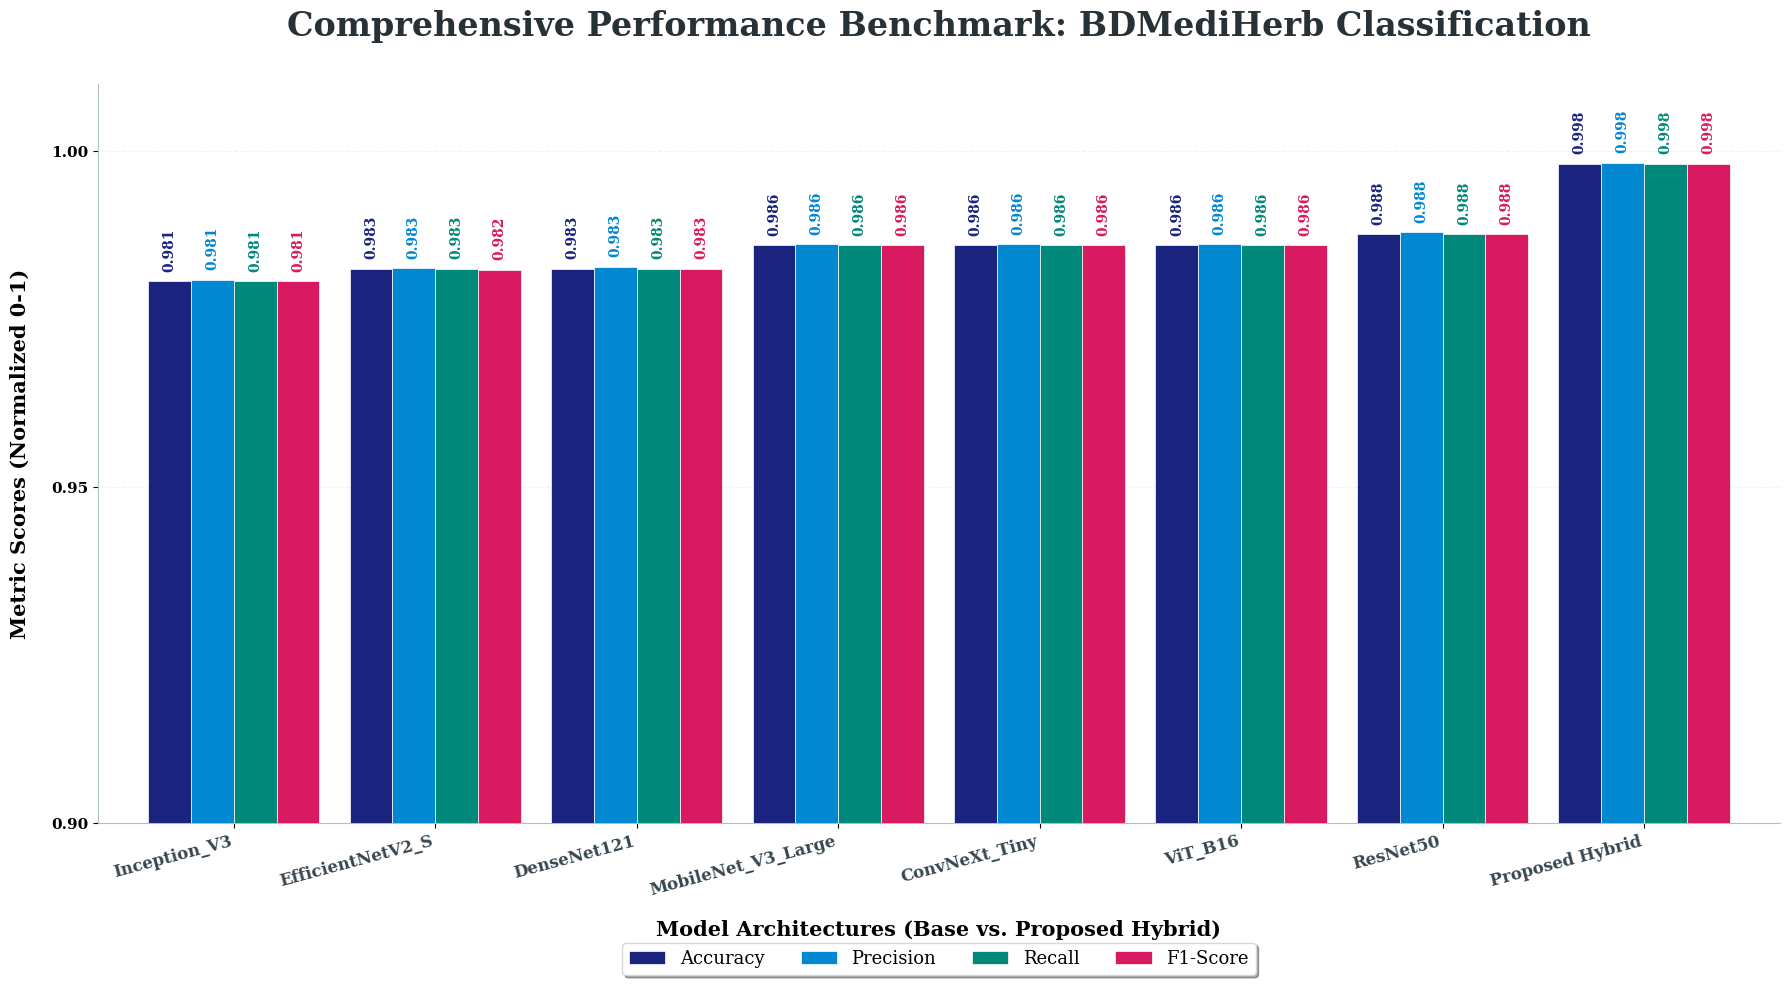

In [ ]:
# ==============================================================================
# PHASE 10: COMPARATIVE PERFORMANCE ANALYSIS VISUALIZATION (PREMIUM RESEARCH)
# Artifact: Grouped Bar Chart with Base Models + Proposed Hybrid
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

print("\n" + "="*80)
print("[INFO] Generating High-Resolution Comparative Performance Charts...")
print("="*80)

comparison_metrics = []
# Base models + Hybrid model search list
MODELS_TO_PLOT = BASE_MODELS + ["Hybrid_TripleStream"]

# 1. DATA EXTRACTION LOGIC
# ------------------------------------------------------------------------------
for name in MODELS_TO_PLOT:
    model_folder = os.path.join(PROJECT_ROOT, name)

    # Adaptive file naming for Hybrid vs Base models
    if name == "Hybrid_TripleStream":
        report_path = os.path.join(model_folder, "hybrid_final_metrics_report.csv")
        display_name = "Proposed Hybrid"
    else:
        report_path = os.path.join(model_folder, "final_metrics_report.csv")
        display_name = name

    if os.path.exists(report_path):
        # Load the classification report CSV
        df_rep = pd.read_csv(report_path, index_col=0)

        # Extract Metrics (Handling row/column structure precisely)
        acc = df_rep.loc['accuracy', 'f1-score'] if 'accuracy' in df_rep.index else 0
        prec = df_rep.loc['weighted avg', 'precision']
        rec = df_rep.loc['weighted avg', 'recall']
        f1 = df_rep.loc['weighted avg', 'f1-score']

        comparison_metrics.append({
            'Model': display_name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })

# 2. DATA PREPARATION
# ------------------------------------------------------------------------------
if comparison_metrics:
    df_metrics = pd.DataFrame(comparison_metrics)
    # Sorting by F1-Score to show performance hierarchy
    df_metrics = df_metrics.sort_values(by='F1-Score', ascending=True)

    # 3. PREMIUM VISUALIZATION STYLING
    # ------------------------------------------------------------------------------
    plt.rcParams['font.family'] = 'serif'
    # Professional Palette: Navy, Ocean, Teal, Rose-Gold
    modern_colors = ['#1A237E', '#0288D1', '#00897B', '#D81B60']

    fig, ax = plt.subplots(figsize=(18, 10), facecolor='white')

    # Grouped Bar Plot
    bars_plot = df_metrics.plot(x='Model', kind='bar', y=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                                width=0.85, color=modern_colors, ax=ax, edgecolor='white',
                                linewidth=0.5, zorder=3)

    # STRICT Y-AXIS CONFIGURATION (Max 1.00)
    # ------------------------------------------------------------------------------
    y_min = max(0, df_metrics[['Accuracy', 'Precision', 'Recall', 'F1-Score']].min().min() - 0.08)
    ax.set_ylim(y_min, 1.01) # 1.08 gives space for text labels without exceeding 1.0 in scale
    plt.yticks(np.arange(round(y_min, 1), 1.01, 0.05), fontsize=11, fontweight='bold')

    # Styling Grid & Borders
    ax.yaxis.grid(True, linestyle='--', color='#ECEFF1', alpha=0.7, zorder=0)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#B0BEC5')
    ax.spines['bottom'].set_color('#B0BEC5')

    # Labels & Title
    ax.set_title("Comprehensive Performance Benchmark: BDMediHerb Classification",
                 fontsize=24, fontweight='bold', pad=35, color='#263238')
    ax.set_xlabel("Model Architectures (Base vs. Proposed Hybrid)", fontsize=15, labelpad=15, fontweight='bold')
    ax.set_ylabel("Metric Scores (Normalized 0-1)", fontsize=15, labelpad=15, fontweight='bold')

    plt.xticks(rotation=15, ha='right', fontsize=12, fontweight='bold', color='#37474F')

    # Legend Customization
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4,
              frameon=True, fontsize=13, shadow=True, edgecolor='#CFD8DC')

    # 4. SCIENTIFIC ANNOTATIONS (Values on top of bars)
    # ------------------------------------------------------------------------------
    for p in ax.patches:
        val = p.get_height()
        if val > 0:
            ax.annotate(f'{val:.3f}',
                        (p.get_x() + p.get_width() / 2., val),
                        ha='center', va='bottom', xytext=(0, 7),
                        textcoords='offset points', fontsize=10,
                        fontweight='black', rotation=90, color=p.get_facecolor())

    plt.tight_layout()

    # 5. HIGH-RESOLUTION EXPORT
    # ------------------------------------------------------------------------------
    save_viz_path = os.path.join(PROJECT_ROOT, 'Global_Research_Comparison_Viz.png')
    plt.savefig(save_viz_path, dpi=400, bbox_inches='tight') # 400 DPI for ultra-sharp journal print

    print(f"\n[SUCCESS] Master Comparative Chart saved at: {save_viz_path}")
    plt.show()

else:
    print("[ERROR] Metric files not found. Ensure evaluation phases were executed for all models.")


[INFO] Generating Professional Inference Speed Analysis (in ms)...
[SUCCESS] Complexity Chart saved at: /content/drive/MyDrive/BDMediHerb/Outputs/Hybrid_Latency_ms_Analysis.png


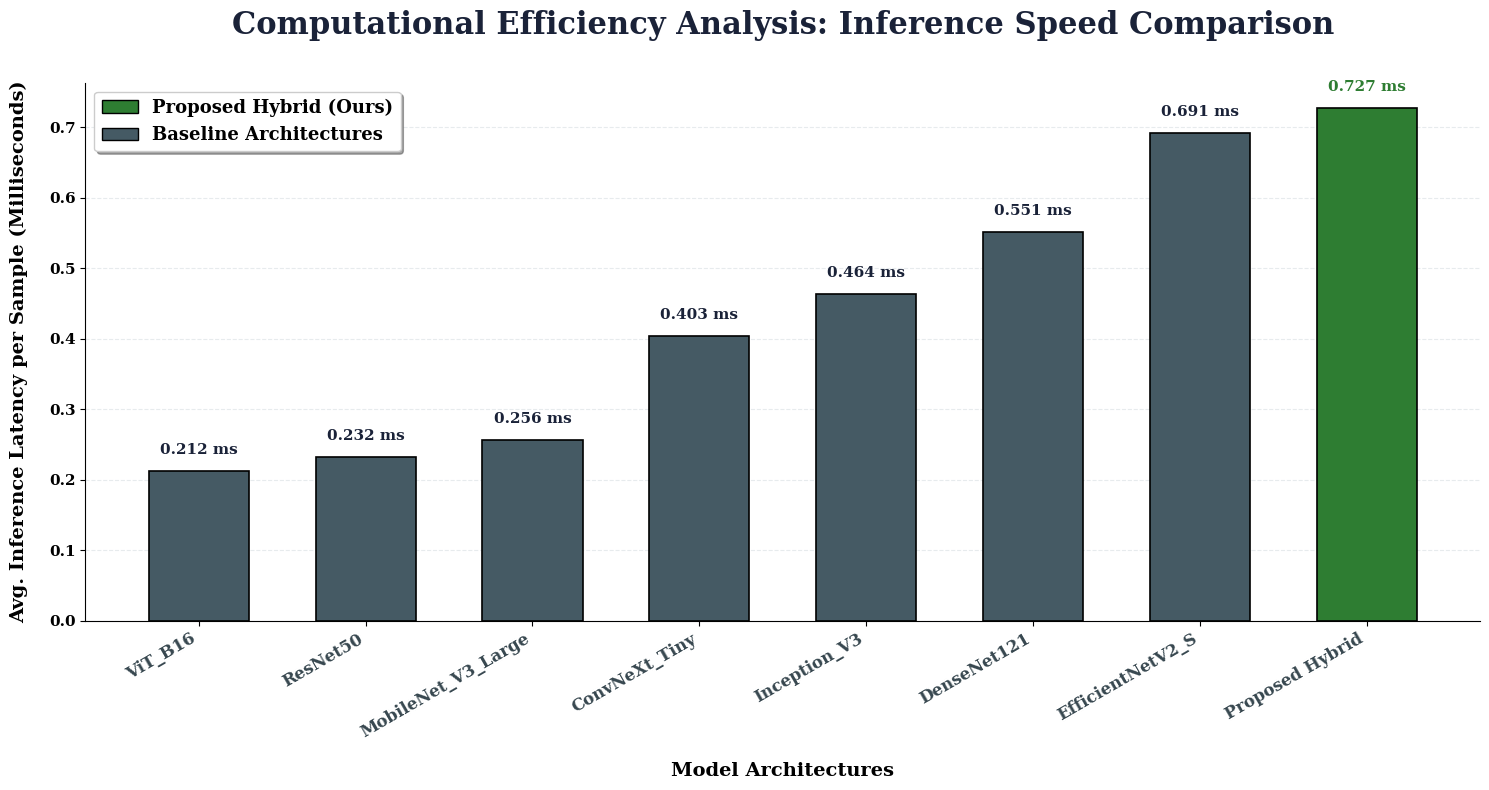

In [ ]:
# ==============================================================================
# PHASE 11: COMPUTATIONAL COMPLEXITY ANALYSIS - INFERENCE LATENCY (IN MS)
# Strategy: Highlighting the Proposed Hybrid Model for Research Validation
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import os

print("\n" + "="*80)
print("[INFO] Generating Professional Inference Speed Analysis (in ms)...")
print("="*80)

inf_summary = {}

# Use the list you defined earlier
BASE_MODELS = [
    "MobileNet_V3_Large", "EfficientNetV2_S", "ResNet50",
    "DenseNet121", "ViT_B16", "Inception_V3", "ConvNeXt_Tiny"
]
MODELS_TO_COMPARE = BASE_MODELS + ["Hybrid_TripleStream"]

# 1. DATA EXTRACTION LOGIC
# ------------------------------------------------------------------------------
for name in MODELS_TO_COMPARE:
    model_folder = os.path.join(PROJECT_ROOT, name)

    if name == "Hybrid_TripleStream":
        history_path = os.path.join(model_folder, "hybrid_training_history.csv")
        display_name = "Proposed Hybrid"
    else:
        history_path = os.path.join(model_folder, "training_history.csv")
        display_name = name

    if os.path.exists(history_path):
        df_log = pd.read_csv(history_path)
        # KEEP IT IN MILLISECONDS (ms) - removed the /1000 division
        mean_latency_ms = df_log['inf_ms'].mean()
        inf_summary[display_name] = mean_latency_ms

# Sorting models by latency (Fastest to Slowest)
sorted_inf = dict(sorted(inf_summary.items(), key=lambda item: item[1]))
model_names = list(sorted_inf.keys())
latency_values = list(sorted_inf.values())

# ------------------------------------------------------------------------------
# 2. DESIGN LOGIC
# ------------------------------------------------------------------------------
plt.rcParams.update({'font.family': 'serif', 'font.weight': 'bold'})
fig, ax = plt.subplots(figsize=(15, 8), facecolor='white')

proposed_color = '#2E7D32'  # Forest Green
base_color = '#455A64'      # Slate Grey

colors = [proposed_color if "Proposed" in n or "Hybrid" in n else base_color for n in model_names]

# 3. PLOTTING
# ------------------------------------------------------------------------------
bars = ax.bar(model_names, latency_values, color=colors, edgecolor='black',
              linewidth=1.2, width=0.6, zorder=3)

# Title and Axis Labels (Updated to Milliseconds)
ax.set_title("Computational Efficiency Analysis: Inference Speed Comparison",
              fontsize=22, fontweight='bold', pad=35, color='#1A2238')
ax.set_ylabel("Avg. Inference Latency per Sample (Milliseconds)", fontsize=14, fontweight='bold', labelpad=15)
ax.set_xlabel("Model Architectures", fontsize=14, fontweight='bold', labelpad=15)

plt.xticks(rotation=30, ha='right', fontsize=12, fontweight='bold', color='#37474F')
plt.yticks(fontsize=11)

ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='#B0BEC5', zorder=0)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# 4. SCIENTIFIC ANNOTATIONS (Latency in ms)
# ------------------------------------------------------------------------------
for bar in bars:
    height = bar.get_height()
    is_proposed = "Proposed" in model_names[bars.index(bar)]
    text_color = proposed_color if is_proposed else '#1A2238'

    # Display with 3 decimal places for millisecond precision
    ax.annotate(f'{height:.3f} ms',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 10), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='black',
                color=text_color)

# 5. LEGEND & EXPORT
# ------------------------------------------------------------------------------
legend_elements = [
    Patch(facecolor=proposed_color, edgecolor='black', label='Proposed Hybrid (Ours)'),
    Patch(facecolor=base_color, edgecolor='black', label='Baseline Architectures')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=13, frameon=True, shadow=True)

plt.tight_layout()
complexity_save_path = os.path.join(PROJECT_ROOT, 'Hybrid_Latency_ms_Analysis.png')
plt.savefig(complexity_save_path, dpi=400, bbox_inches='tight')

print(f"[SUCCESS] Complexity Chart saved at: {complexity_save_path}")
plt.show()


                       [SYSTEM] ANALYZING LEARNING RATE CONVERGENCE DYNAMICS                        

[SUCCESS] Global Learning Rate chart archived at: /content/drive/MyDrive/BDMediHerb/Outputs/Master_LR_Convergence_Analysis.png


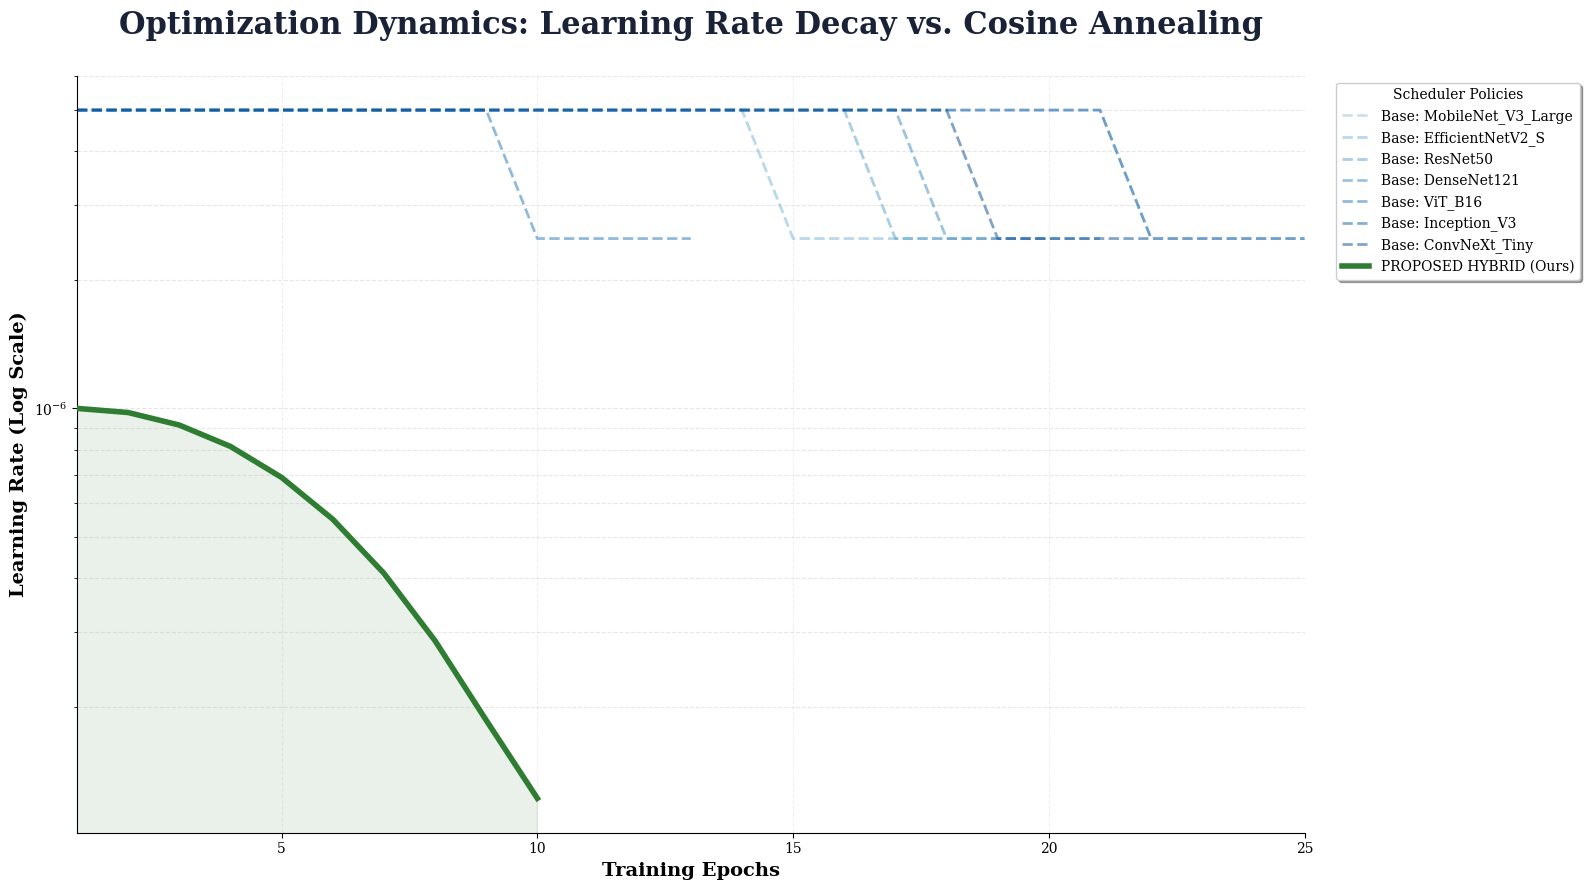

In [ ]:
# ==============================================================================
# PHASE 12: OPTIMIZATION DYNAMICS - MASTER LR ANALYSIS (FIXED PATHS)
# Strategy: Visualizing Learning Rate Evolution Across All Models
# ==============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

print("\n" + "="*100)
print(f"{'[SYSTEM] ANALYZING LEARNING RATE CONVERGENCE DYNAMICS':^100}")
print("="*100)

# 1. SETUP & PATH CONFIGURATION
# ------------------------------------------------------------------------------
PROJECT_ROOT = "/content/drive/MyDrive/BDMediHerb/Outputs"
BASE_MODELS = [
    "MobileNet_V3_Large", "EfficientNetV2_S", "ResNet50",
    "DenseNet121", "ViT_B16", "Inception_V3", "ConvNeXt_Tiny"
]
HYBRID_MODEL = "Hybrid_TripleStream"

plt.figure(figsize=(16, 9), facecolor='white')
plt.rcParams.update({'font.family': 'serif', 'font.weight': 'medium'})

# Professional Palette: Slate Blues for Base, Vibrant Emerald for Hybrid
base_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(BASE_MODELS)))
hybrid_color = '#2E7D32'

max_epochs = 0

# 2. PLOTTING BASE MODELS (From training_history.csv)
# ------------------------------------------------------------------------------
for i, name in enumerate(BASE_MODELS):
    # Standard history file for individual models
    history_path = os.path.join(PROJECT_ROOT, name, "training_history.csv")

    if os.path.exists(history_path):
        try:
            df = pd.read_csv(history_path)
            if 'lr' in df.columns:
                epochs = df['epoch'] if 'epoch' in df.columns else range(1, len(df)+1)
                plt.plot(epochs, df['lr'], label=f'Base: {name}',
                         color=base_colors[i], linewidth=2, alpha=0.5, linestyle='--')
                max_epochs = max(max_epochs, epochs.max() if isinstance(epochs, pd.Series) else len(epochs))
        except Exception as e:
            print(f"[ERR] Error reading {name}: {e}")
    else:
        print(f"[SKIP] {name} -> training_history.csv not found.")

# 3. PLOTTING PROPOSED HYBRID (From hybrid_training_history.csv)
# ------------------------------------------------------------------------------
hybrid_path = os.path.join(PROJECT_ROOT, HYBRID_MODEL, "hybrid_training_history.csv")

if os.path.exists(hybrid_path):
    try:
        df_hyb = pd.read_csv(hybrid_path)
        if 'lr' in df_hyb.columns:
            hyb_epochs = df_hyb['epoch'] if 'epoch' in df_hyb.columns else range(1, len(df_hyb)+1)
            # Plotting the wave-like pattern of Cosine Annealing
            plt.plot(hyb_epochs, df_hyb['lr'], label='PROPOSED HYBRID (Ours)',
                     color=hybrid_color, linewidth=4, zorder=10)

            # Adding a subtle fill for premium visualization
            plt.fill_between(hyb_epochs, df_hyb['lr'], color=hybrid_color, alpha=0.1)
            max_epochs = max(max_epochs, hyb_epochs.max() if isinstance(hyb_epochs, pd.Series) else len(hyb_epochs))
    except Exception as e:
        print(f"[ERR] Error reading Hybrid Model: {e}")
else:
    print(f"[WARNING] Hybrid history NOT found at: {hybrid_path}")

# 4. SCIENTIFIC GRAPH AESTHETICS (Q1 Journal Standard)
# ------------------------------------------------------------------------------
plt.yscale('log') # Essential to see the magnitude of LR shifts clearly
plt.title("Optimization Dynamics: Learning Rate Decay vs. Cosine Annealing",
          fontsize=22, fontweight='bold', pad=30, color='#1A2238')
plt.xlabel("Training Epochs", fontsize=14, fontweight='bold')
plt.ylabel("Learning Rate (Log Scale)", fontsize=14, fontweight='bold')

# Grid and Spine Styling
ax = plt.gca()
ax.yaxis.grid(True, which='both', linestyle='--', alpha=0.3)
ax.xaxis.grid(True, linestyle='--', alpha=0.2)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# Legend positioning
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10,
           frameon=True, shadow=True, title="Scheduler Policies")

plt.xlim(1, max_epochs)
plt.tight_layout()

# 5. EXPORT
# ------------------------------------------------------------------------------
lr_save_path = os.path.join(PROJECT_ROOT, "Master_LR_Convergence_Analysis.png")
plt.savefig(lr_save_path, dpi=400, bbox_inches='tight')

print(f"\n[SUCCESS] Global Learning Rate chart archived at: {lr_save_path}")
plt.show()


               [SYSTEM] INITIATING GLOBAL ERROR ANALYSIS PIPELINE               
[FOUND] MobileNet_V3_Large        | Errors: 8
[FOUND] EfficientNetV2_S          | Errors: 10
[FOUND] ResNet50                  | Errors: 7
[FOUND] DenseNet121               | Errors: 10
[FOUND] ViT_B16                   | Errors: 8
[FOUND] Inception_V3              | Errors: 11
[FOUND] ConvNeXt_Tiny             | Errors: 8
[FOUND] Proposed Hybrid           | Errors: 1

[SUCCESS] Error Comparison Chart saved at: /content/drive/MyDrive/BDMediHerb/Outputs/Global_Error_Analysis/Hybrid_Error_Reduction_Benchmark.png


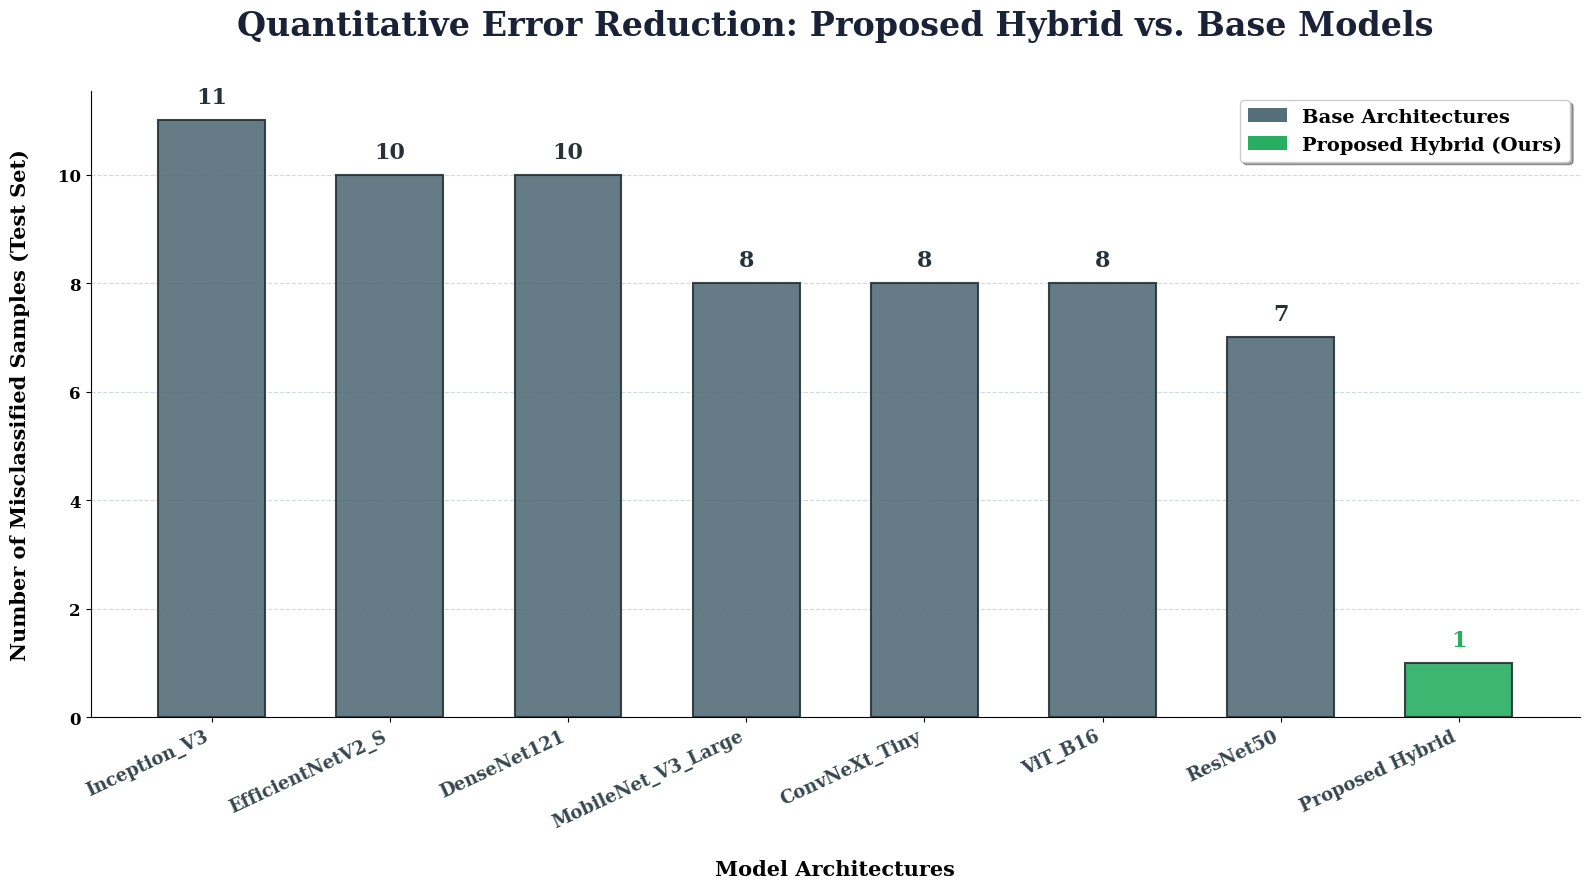

In [ ]:
# ==============================================================================
# PHASE 13: GLOBAL MISCLASSIFICATION ANALYSIS - ERROR REDUCTION VISUALIZATION
# Strategy: Dynamic File Resolution | High-Resolution Research Graphics
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
from matplotlib.patches import Patch

print("\n" + "="*80)
print(f"{'[SYSTEM] INITIATING GLOBAL ERROR ANALYSIS PIPELINE':^80}")
print("="*80)

# 1. SETUP & DIRECTORY CONFIGURATION
# ------------------------------------------------------------------------------
error_viz_dir = os.path.join(PROJECT_ROOT, "Global_Error_Analysis")
os.makedirs(error_viz_dir, exist_ok=True)

# Correct model list provided by you
MODEL_LIST = ["MobileNet_V3_Large", "EfficientNetV2_S", "ResNet50", "DenseNet121", "ViT_B16", "Inception_V3", "ConvNeXt_Tiny"]
MODELS_TO_ANALYZE = MODEL_LIST + ["Hybrid_TripleStream"]

error_summary_data = []

# 2. DYNAMIC DATA AGGREGATION
# ------------------------------------------------------------------------------
for name in MODELS_TO_ANALYZE:
    model_folder = os.path.join(PROJECT_ROOT, name)

    # [LOGIC FIX] Selecting filenames based on your input
    if "Hybrid" in name:
        error_file = "misclassifications.csv"
        display_name = "Proposed Hybrid"
        is_hybrid = True
    else:
        error_file = "detailed_misclassifications.csv"
        display_name = name
        is_hybrid = False

    error_log_path = os.path.join(model_folder, error_file)

    if os.path.exists(error_log_path):
        try:
            df_errors = pd.read_csv(error_log_path)
            error_count = len(df_errors)
            error_summary_data.append({
                'Model': display_name,
                'Total Errors': error_count,
                'IsHybrid': is_hybrid
            })
            print(f"[FOUND] {display_name:<25} | Errors: {error_count}")
        except Exception as e:
            print(f"[ERR] Could not read {error_file} for {name}: {e}")
    else:
        # Fallback: Check if the other filename exists just in case
        alt_file = "misclassifications.csv" if not is_hybrid else "detailed_misclassifications.csv"
        alt_path = os.path.join(model_folder, alt_file)

        if os.path.exists(alt_path):
            error_count = len(pd.read_csv(alt_path))
            error_summary_data.append({'Model': display_name, 'Total Errors': error_count, 'IsHybrid': is_hybrid})
            print(f"[FOUND] {display_name:<25} (Alt Path) | Errors: {error_count}")
        else:
            print(f"[MISSING] No error logs found for {name} in {model_folder}")

# Sort for impactful visualization
df_err_plot = pd.DataFrame(error_summary_data).sort_values('Total Errors', ascending=False)

# ------------------------------------------------------------------------------
# 3. PREMIUM VISUALIZATION (Emerald & Slate Palette)
# ------------------------------------------------------------------------------
plt.figure(figsize=(16, 9), facecolor='white')
plt.rcParams.update({'font.family': 'serif', 'font.weight': 'bold'})

base_color = '#546E7A'      # Professional Slate Grey
proposed_color = '#27AE60'  # Research Emerald Green

colors = [proposed_color if row['IsHybrid'] else base_color for _, row in df_err_plot.iterrows()]

bars = plt.bar(df_err_plot['Model'], df_err_plot['Total Errors'],
                color=colors, edgecolor='#263238', linewidth=1.5, width=0.6, alpha=0.9, zorder=3)

# Aesthetics
plt.title("Quantitative Error Reduction: Proposed Hybrid vs. Base Models",
          fontsize=24, pad=40, fontweight='black', color='#1A2238')
plt.ylabel("Number of Misclassified Samples (Test Set)", fontsize=15, labelpad=20, fontweight='bold')
plt.xlabel("Model Architectures", fontsize=15, labelpad=20, fontweight='bold')

ax = plt.gca()
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#90A4AE', zorder=0)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.xticks(rotation=25, ha='right', fontsize=13, fontweight='bold', color='#37474F')
plt.yticks(fontsize=12)

# 4. ANNOTATION LOGIC
# ------------------------------------------------------------------------------
max_error = df_err_plot['Total Errors'].max() if not df_err_plot.empty else 1
for bar in bars:
    height = bar.get_height()
    # Dynamic text coloring
    current_model = df_err_plot.iloc[bars.index(bar)]['Model']
    text_color = proposed_color if "Proposed" in current_model else '#263238'

    plt.text(bar.get_x() + bar.get_width()/2., height + (max_error * 0.02),
             f'{int(height)}', ha='center', va='bottom',
             fontsize=16, fontweight='black', color=text_color)

# Legend
legend_elements = [
    Patch(facecolor=base_color, label='Base Architectures'),
    Patch(facecolor=proposed_color, label='Proposed Hybrid (Ours)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=14, frameon=True, shadow=True)

plt.tight_layout()

# 5. HIGH-RESOLUTION EXPORT
# ------------------------------------------------------------------------------
final_save_path = os.path.join(error_viz_dir, "Hybrid_Error_Reduction_Benchmark.png")
plt.savefig(final_save_path, dpi=450, bbox_inches='tight')

print(f"\n[SUCCESS] Error Comparison Chart saved at: {final_save_path}")
plt.show()

[INFO] Generating Precise 4x4 XAI Grid. This will take a moment...


  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

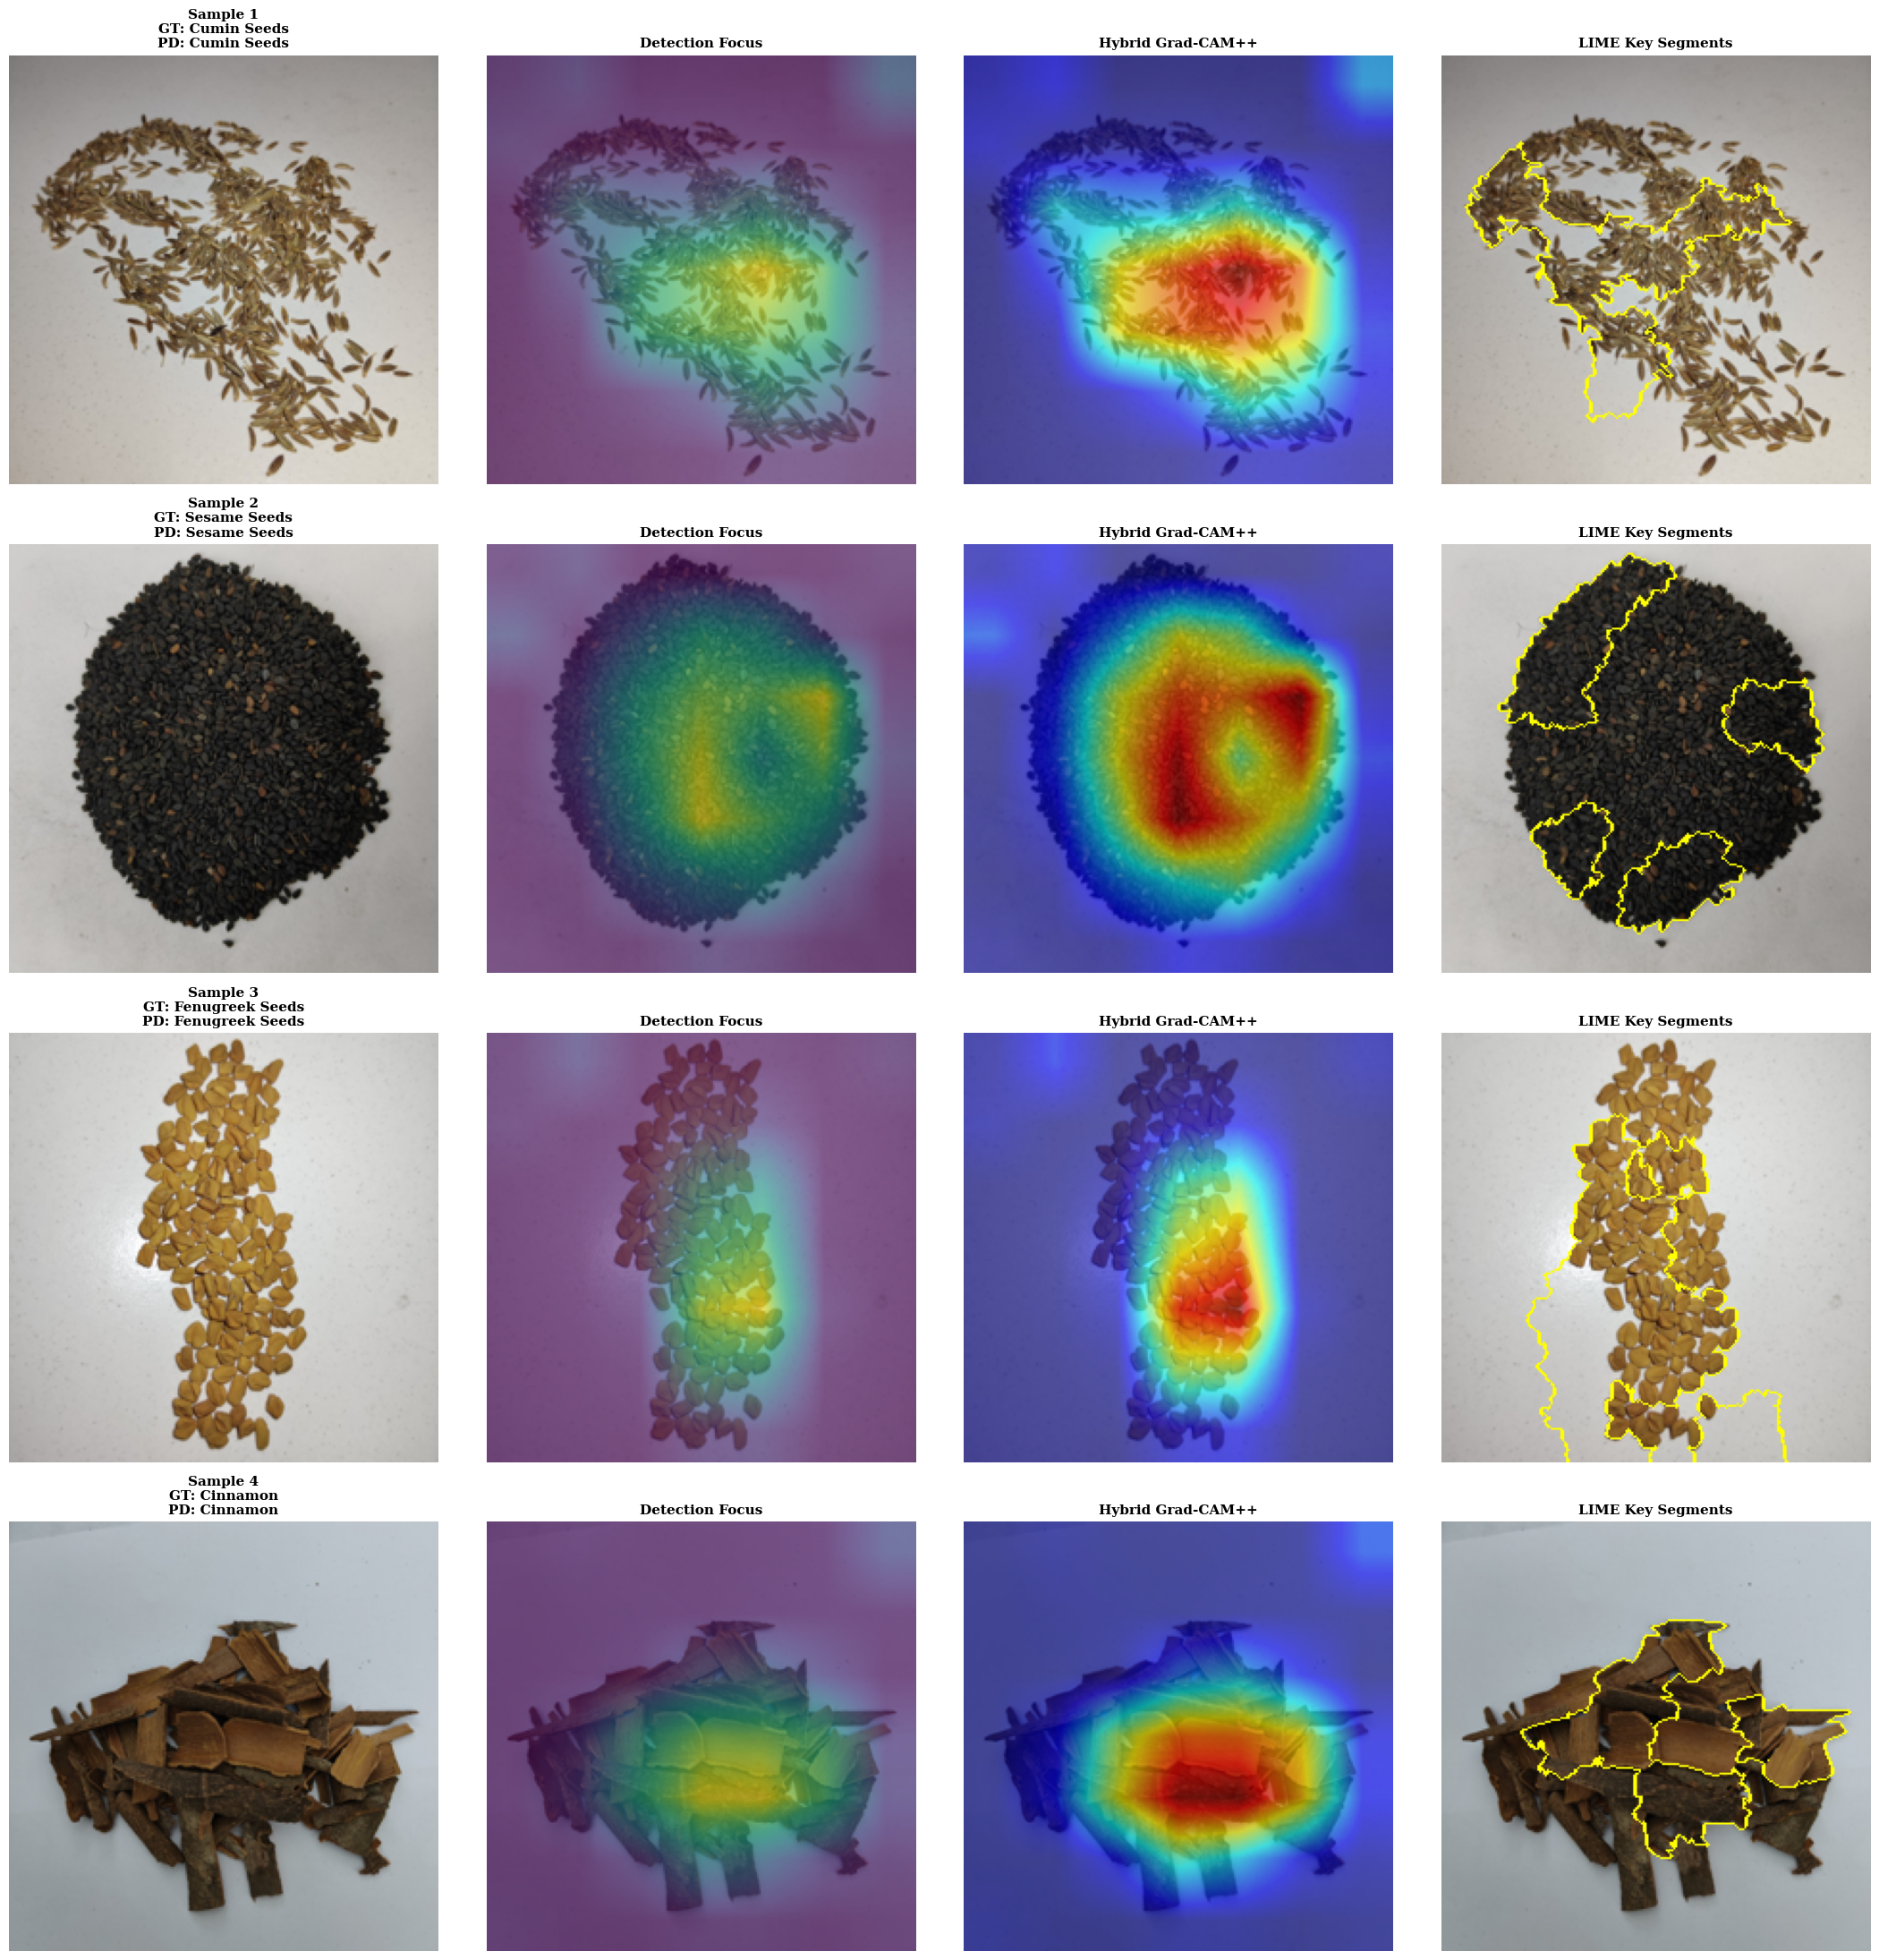


[SUCCESS] Pipeline Completed! Precise results saved at: /content/drive/MyDrive/BDMediHerb/Outputs/Hybrid_TripleStream/XAI_Deep_Analysis/Master_XAI_Precision_Grid.png


In [ ]:
# ==============================================================================
# PHASE 14: HIGH-PRECISION XAI SUITE (SPATIAL GRAD-CAM++ & LIME)
# Strategy: Backbone Hooking | Contrast Stretching | Multi-Layer Interpretability
# ==============================================================================

import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# 1. DIRECTORY & TRANSFORM SETUP
# ------------------------------------------------------------------------------
XAI_REPORT_DIR = os.path.join(EXPORT_DIR_HYB, "XAI_Deep_Analysis")
os.makedirs(XAI_REPORT_DIR, exist_ok=True)

xai_transforms = transforms.Compose([
    transforms.Resize((HYBRID_RES, HYBRID_RES)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. HEATMAP UTILITY (IMPROVED CONTRAST)
# ------------------------------------------------------------------------------
def overlay_heatmap(img, mask, colormap=cv2.COLORMAP_JET, alpha=0.6):
    """Overlays a spatial mask onto the image with high contrast."""
    img_np = np.array(img.resize((HYBRID_RES, HYBRID_RES)))
    # Contrast Stretching
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    mask_np = np.uint8(255 * mask)
    heatmap = cv2.applyColorMap(mask_np, colormap)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img_np, 1 - alpha, heatmap, alpha, 0)

# 3. MODEL PREP & BACKBONE HOOKING
# ------------------------------------------------------------------------------
model_xai = EnsembleStackingNet(BEST_3_NAMES).to(DEVICE)
model_xai.load_state_dict(torch.load(os.path.join(EXPORT_DIR_HYB, "best_hybrid_model.pth")))
model_xai.eval()

# Storage for spatial features and gradients
hybrid_spatial_blobs = {'features': None, 'gradients': None}

def spatial_forward_hook(module, input, output):
    hybrid_spatial_blobs['features'] = output.detach()

def spatial_backward_hook(module, grad_in, grad_out):
    hybrid_spatial_blobs['gradients'] = grad_out[0].detach()

# [CRITICAL] Hooking into ResNet Stream's spatial layer for precise localization
target_layer = model_xai.stream2.backbone.layer4
target_layer.register_forward_hook(spatial_forward_hook)
target_layer.register_full_backward_hook(spatial_backward_hook)

# 4. PRECISE GRAD-CAM++ CORE
# ------------------------------------------------------------------------------
def generate_spatial_cam_pp(model, input_tensor, target_cls):
    model.zero_grad()
    logits = model(input_tensor)
    score = logits[0, target_cls]
    score.backward()

    grads = hybrid_spatial_blobs['gradients'] # Spatial Grads (e.g., [1, 2048, 7, 7])
    acts = hybrid_spatial_blobs['features']   # Spatial Features (e.g., [1, 2048, 7, 7])

    # Calculate Weights using Grad-CAM++ Logic
    grads_pow2 = grads.pow(2)
    grads_pow3 = grads.pow(3)
    sum_act = torch.sum(acts, dim=(2, 3), keepdim=True)
    eps = 1e-8

    aij = grads_pow2 / (2 * grads_pow2 + sum_act * grads_pow3 + eps)
    weights = torch.sum(aij * torch.clamp(grads, min=0), dim=(2, 3), keepdim=True)

    # Create the heatmap by weighting the activation maps
    cam = torch.sum(weights * acts, dim=1).squeeze().cpu().numpy()
    cam = np.maximum(cam, 0) # ReLU to keep only positive influence
    return cv2.resize(cam, (HYBRID_RES, HYBRID_RES))

# 5. MASTER 4x4 VISUALIZATION GENERATOR
# ------------------------------------------------------------------------------
print("[INFO] Generating Precise 4x4 XAI Grid. This will take a moment...")

explainer = lime_image.LimeImageExplainer(random_state=42)
test_samples = np.random.choice(hybrid_test_idx, 4, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(22, 22), facecolor='white')
plt.subplots_adjust(wspace=0.1, hspace=0.3)

for row, idx in enumerate(test_samples):
    img_path, true_cls = hybrid_ds_raw.samples[idx]
    raw_pil = Image.open(img_path).convert("RGB")
    input_tensor = xai_transforms(raw_pil).unsqueeze(0).to(DEVICE)

    # Get Prediction
    logits = model_xai(input_tensor)
    pred_cls = logits.argmax(1).item()

    # Generate Heatmap (Precision Fix)
    spatial_map = generate_spatial_cam_pp(model_xai, input_tensor, pred_cls)

    # --- Col 1: Original Image ---
    axes[row, 0].imshow(np.array(raw_pil.resize((HYBRID_RES, HYBRID_RES))))
    axes[row, 0].set_title(f"Sample {row+1}\nGT: {hybrid_ds_raw.classes[true_cls]}\nPD: {hybrid_ds_raw.classes[pred_cls]}", fontsize=11, fontweight='bold')
    axes[row, 0].axis('off')

    # --- Col 2: Feature Activation (Detection) ---
    axes[row, 1].imshow(overlay_heatmap(raw_pil, spatial_map, colormap=cv2.COLORMAP_VIRIDIS))
    axes[row, 1].set_title("Detection Focus", fontsize=11, fontweight='bold')
    axes[row, 1].axis('off')

    # --- Col 3: Precise Grad-CAM++ ---
    axes[row, 2].imshow(overlay_heatmap(raw_pil, spatial_map, colormap=cv2.COLORMAP_JET))
    axes[row, 2].set_title("Hybrid Grad-CAM++", fontsize=11, fontweight='bold')
    axes[row, 2].axis('off')

    # --- Col 4: LIME Segmentation ---
    def lime_predict(imgs):
        batch = torch.stack([xai_transforms(Image.fromarray(i)) for i in imgs]).to(DEVICE)
        return F.softmax(model_xai(batch), dim=1).detach().cpu().numpy()

    explanation = explainer.explain_instance(np.array(raw_pil.resize((HYBRID_RES, HYBRID_RES))),
                                             lime_predict, top_labels=1, num_samples=300)
    temp, mask = explanation.get_image_and_mask(pred_cls, positive_only=True, num_features=5, hide_rest=False)
    axes[row, 3].imshow(mark_boundaries(temp/255.0, mask))
    axes[row, 3].set_title("LIME Key Segments", fontsize=11, fontweight='bold')
    axes[row, 3].axis('off')

plt.tight_layout()
master_xai_path = os.path.join(XAI_REPORT_DIR, "Master_XAI_Precision_Grid.png")
plt.savefig(master_xai_path, dpi=300)
plt.show()

print(f"\n[SUCCESS] Pipeline Completed! Precise results saved at: {master_xai_path}")


                     [SYSTEM] RE-INITIALIZING XAI PIPELINE                      
[INFO] Generating XAI Master Grid. This may take a minute...


  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

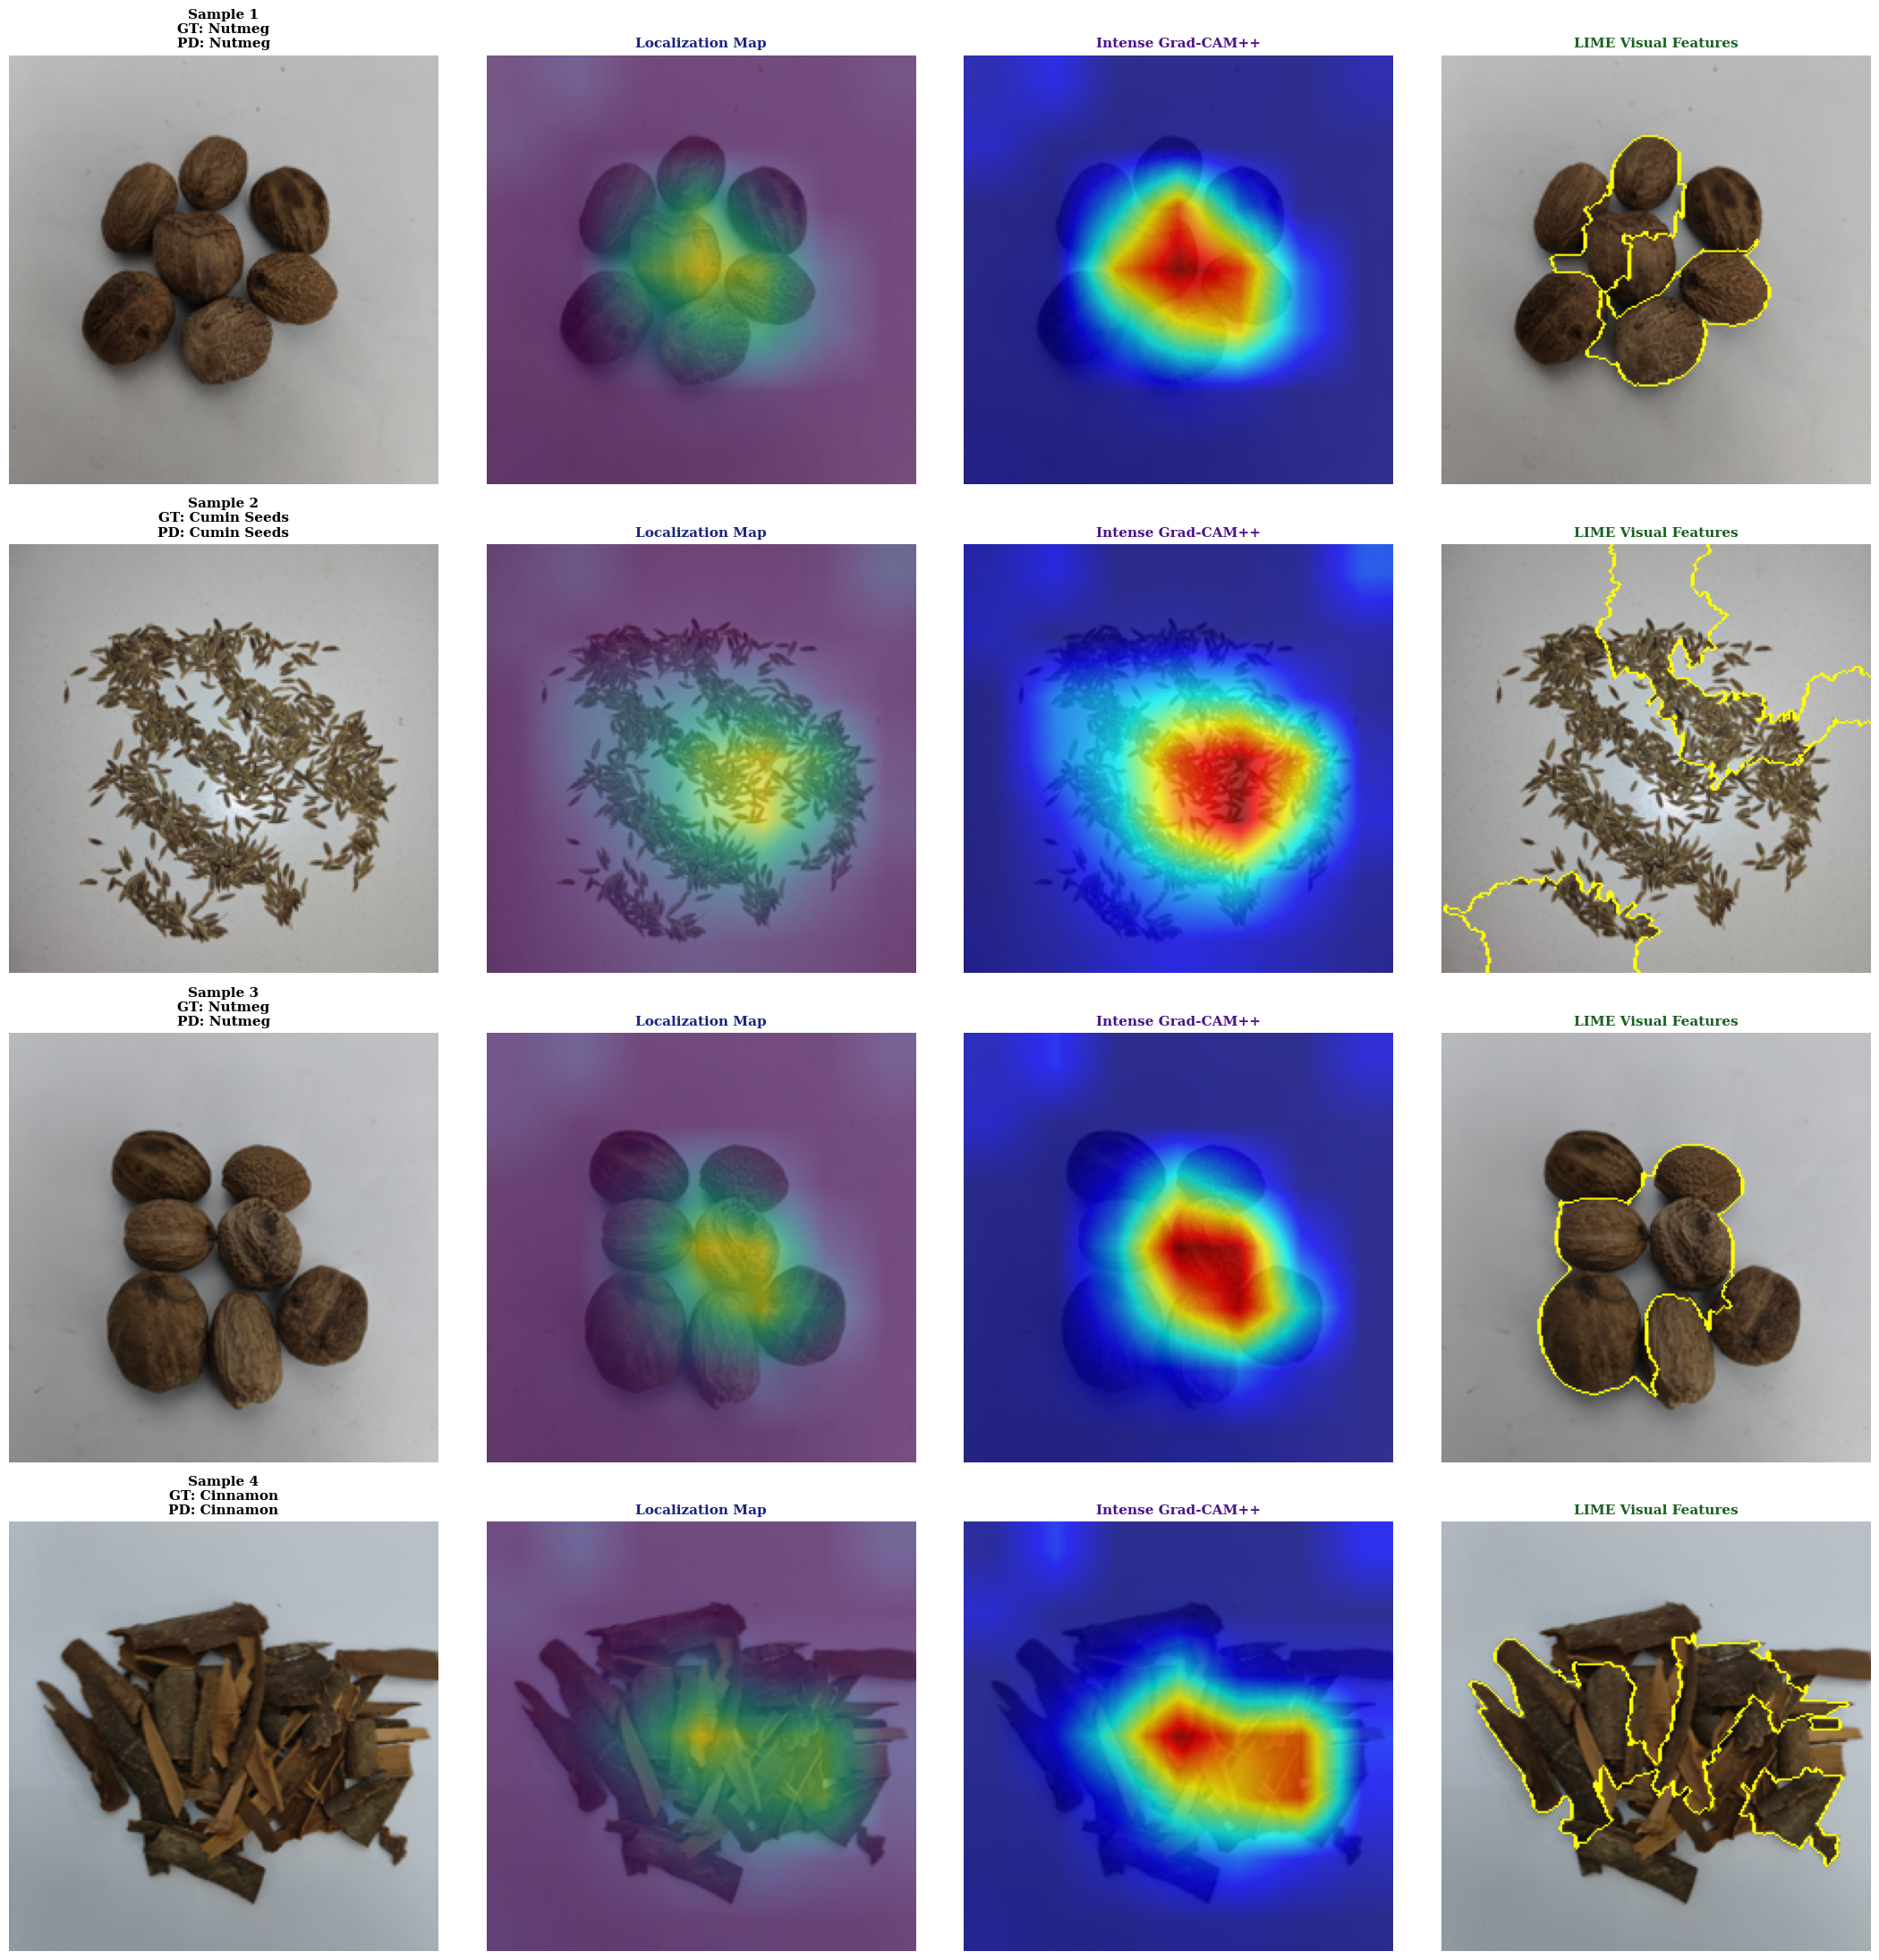


[SUCCESS] Master XAI Grid saved in: /content/drive/MyDrive/BDMediHerb/Outputs/Hybrid_TripleStream/XAI_Precision_Final


In [ ]:
# ==============================================================================
# PHASE 14: FINAL PRECISION XAI PIPELINE
# Target: Backbone Layer4 | Intense Color Output | Hook Sync
# ==============================================================================

import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

print("\n" + "="*80)
print(f"{'[SYSTEM] RE-INITIALIZING XAI PIPELINE':^80}")
print("="*80)

# 1. SETUP & UTILITIES
# ------------------------------------------------------------------------------
XAI_REPORT_DIR = os.path.join(PROJECT_ROOT, "Hybrid_TripleStream", "XAI_Precision_Final")
os.makedirs(XAI_REPORT_DIR, exist_ok=True)

xai_transforms = transforms.Compose([
    transforms.Resize((HYBRID_RES, HYBRID_RES)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def overlay_intense_heatmap(img, mask, colormap=cv2.COLORMAP_JET, alpha=0.7):
    """Overlays heatmap with deep intensity and contrast stretching."""
    img_np = np.array(img.resize((HYBRID_RES, HYBRID_RES)))
    mask_scaled = np.uint8(255 * mask)
    heatmap = cv2.applyColorMap(mask_scaled, colormap)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img_np, 1 - alpha, heatmap, alpha, 0)

# 2. MODEL PREP & HOOK REGISTRATION
# ------------------------------------------------------------------------------
model_xai = EnsembleStackingNet(BEST_3_NAMES).to(DEVICE)
model_xai.load_state_dict(torch.load(os.path.join(PROJECT_ROOT, "Hybrid_TripleStream", "best_hybrid_model.pth")))
model_xai.eval()

# Ensure gradients are enabled for XAI computation
for param in model_xai.parameters():
    param.requires_grad = True

xai_blobs = {'features': None, 'gradients': None}

def forward_hook_fn(module, input, output):
    xai_blobs['features'] = output.detach()

def backward_hook_fn(module, grad_in, grad_out):
    xai_blobs['gradients'] = grad_out[0].detach()

# [FIXED] Registering hooks to ResNet stream's last spatial layer
target_layer = model_xai.stream2.backbone.layer4
target_layer.register_forward_hook(forward_hook_fn)
target_layer.register_full_backward_hook(backward_hook_fn)

# 3. GRAD-CAM++ LOGIC (PRECISION FIX)
# ------------------------------------------------------------------------------
def generate_precise_cam_pp(model, input_tensor, target_cls):
    model.zero_grad()
    logits = model(input_tensor)

    # Calculate gradients for the specific class
    score = logits[0, target_cls]
    score.backward()

    grads = xai_blobs['gradients']
    acts = xai_blobs['features']

    if grads is None or acts is None:
        return np.zeros((HYBRID_RES, HYBRID_RES))

    # Grad-CAM++ Weights
    grads_pow2 = grads.pow(2)
    grads_pow3 = grads.pow(3)
    sum_act = torch.sum(acts, dim=(2, 3), keepdim=True)
    eps = 1e-8

    aij = grads_pow2 / (2 * grads_pow2 + sum_act * grads_pow3 + eps)
    weights = torch.sum(aij * torch.clamp(grads, min=0), dim=(2, 3), keepdim=True)

    cam = torch.sum(weights * acts, dim=1).squeeze().cpu().numpy()
    cam = np.maximum(cam, 0)

    # Normalize for visual intensity
    cam = (cam - cam.min()) / (cam.max() - cam.min() + eps)
    return cv2.resize(cam, (HYBRID_RES, HYBRID_RES))

# 4. MASTER 4x4 VISUALIZATION
# ------------------------------------------------------------------------------
print("[INFO] Generating XAI Master Grid. This may take a minute...")
explainer = lime_image.LimeImageExplainer(random_state=42)
test_samples = np.random.choice(hybrid_test_idx, 4, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(22, 22), facecolor='white')
plt.subplots_adjust(wspace=0.1, hspace=0.3)

for row, idx in enumerate(test_samples):
    img_path, true_cls = hybrid_ds_raw.samples[idx]
    raw_pil = Image.open(img_path).convert("RGB")
    input_tensor = xai_transforms(raw_pil).unsqueeze(0).to(DEVICE)

    # Prediction
    logits = model_xai(input_tensor)
    pred_cls = logits.argmax(1).item()

    # Heatmap Generation
    precise_map = generate_precise_cam_pp(model_xai, input_tensor, pred_cls)

    # --- Col 1: Original ---
    axes[row, 0].imshow(np.array(raw_pil.resize((HYBRID_RES, HYBRID_RES))))
    axes[row, 0].set_title(f"Sample {row+1}\nGT: {hybrid_ds_raw.classes[true_cls]}\nPD: {hybrid_ds_raw.classes[pred_cls]}", fontsize=11, fontweight='bold')
    axes[row, 0].axis('off')

    # --- Col 2: Decision Focus (Viridis) ---
    axes[row, 1].imshow(overlay_intense_heatmap(raw_pil, precise_map, colormap=cv2.COLORMAP_VIRIDIS, alpha=0.6))
    axes[row, 1].set_title("Localization Map", fontsize=11, fontweight='bold', color='#1A237E')
    axes[row, 1].axis('off')

    # --- Col 3: Hybrid Grad-CAM++ (Garo Red) ---
    axes[row, 2].imshow(overlay_intense_heatmap(raw_pil, precise_map, colormap=cv2.COLORMAP_JET, alpha=0.75))
    axes[row, 2].set_title("Intense Grad-CAM++", fontsize=11, fontweight='bold', color='#4A148C')
    axes[row, 2].axis('off')

    # --- Col 4: LIME Explanation ---
    def lime_predict(imgs):
        batch = torch.stack([xai_transforms(Image.fromarray(i)) for i in imgs]).to(DEVICE)
        with torch.no_grad():
            output = model_xai(batch)
        return F.softmax(output, dim=1).detach().cpu().numpy()

    explanation = explainer.explain_instance(np.array(raw_pil.resize((HYBRID_RES, HYBRID_RES))),
                                             lime_predict, top_labels=1, num_samples=300)
    temp, mask = explanation.get_image_and_mask(pred_cls, positive_only=True, num_features=5, hide_rest=False)
    axes[row, 3].imshow(mark_boundaries(temp/255.0, mask))
    axes[row, 3].set_title("LIME Visual Features", fontsize=11, fontweight='bold', color='#1B5E20')
    axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(XAI_REPORT_DIR, "Master_XAI_Final_Fixed.png"), dpi=300)
plt.show()

print(f"\n[SUCCESS] Master XAI Grid saved in: {XAI_REPORT_DIR}")